# Static–dynamic scatterplots for reliable channels

For every reliable physical channel, this notebook compares response magnitude and response latency across matched stimuli in the static and dynamic conditions. Latency scatterplots correlate both Gaussian-smoothed peak latency and positive-mass centroid latency for the reliable-channel population and for every single channel. Each point is one matched stimulus.

Edit `Cfg` to choose the sessions, static-frame condition, channel range, response summary, smoothing, and response windows. Windows are half-open: `(start_ms, end_ms)` includes the start and excludes the end. Setting `dynamic_window_ms=None` shifts the static window to the selected frame's time in the movie. The movie window is required to start at or after the configurable cutoff so early video transients cannot become peaks. Channel labels use one-based MATLAB channel numbers.

In [1]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
from scipy.stats import pearsonr, spearmanr, ttest_rel


# Locate the repository whether the notebook starts in the project root or scripts/.
working_directory = Path.cwd().resolve()
project_candidates = (working_directory, *working_directory.parents)
PROJECT_ROOT = next(
    candidate for candidate in project_candidates
    if (candidate / "config.yaml").is_file()
)
ENV = os.getenv("MY_ENV", "tiziano_mac_mini")

with open(PROJECT_ROOT / "config.yaml", "r") as file:
    config = yaml.safe_load(file)
# end with open

if ENV not in config:
    raise KeyError(f"MY_ENV={ENV!r} is not defined in config.yaml.")
# end if ENV missing

paths = config[ENV]["paths"]
for source_path in (paths["src_path"], paths["useful_stuff_path"]):
    if source_path not in sys.path:
        sys.path.append(source_path)
    # end if source_path missing
# end for source_path

from project_specific_utils import (
    load_natraster,
    match_timed_static_movie_rasters,
    plot_static_dynamic_drsa_peak,
    rowwise_similarity,
    static_dynamic_drsa_peak,
    window_mean_responses,
    window_smoothed_response_latencies,
)

## Configuration

`static_response` accepts `"last_frame"`, `"2000ms"`, or `"2250ms"`. Set `response_summary="mean"` for the original window average or `"peak"` for the maximum after Gaussian smoothing. `static_window_ms` and `dynamic_window_ms` define the search windows. `minimum_dynamic_window_start_ms` defaults to 2400 ms and prevents an earlier movie window from accidentally capturing onset activity. `good_channels=None` means that all channels listed as reliable are retained; a tuple intersects the reliable list with that inclusive channel range.

Set `window_source="drsa_peak"` to replace both fixed windows with the timepoints at which the two conditions match best. The static-dynamic dRSA (dynamic time × static time RDM correlation, on the reliable channels and matched stimuli) is computed at `drsa_fs`. Its maximum is searched inside `drsa_static_search_ms` and `drsa_dynamic_search_ms`, and both windows become `peak ± drsa_half_window_ms`. With `drsa_dynamic_search_ms=None`, the dynamic search starts at `minimum_dynamic_window_start_ms` and runs to the end of the movie.


In [11]:
@dataclass
class Cfg:
    static_exp_name: str = "paul_20260901to0923" #"red_20260726to0925" #"baby1_260718to27"# #
    dynamic_exp_name: str = "paul_20260831to0927" #"red_20260720to0927" # "baby1_260716to24"# 
    # Options: "last_frame", "2000ms", or "2250ms".
    static_response: str = "last_frame"

    # MATLAB channel numbers are one-based and both endpoints are inclusive.
    good_channels: tuple[int, int] | None = (1,64)
    reliable_channels_config: Path | None = None
    reliable_channels_key: str | None = "paul_20260901to0923" #"red_20260726to0923" #

    source_fs: float = 1000
    # Options: "mean" or Gaussian-smoothed "peak".
    response_summary: str = "peak"
    gaussian_smoothing_sigma_ms: float = 20
    static_window_ms: tuple[float, float] = (80, 250)
    # None applies static_window_ms relative to the chosen frame's movie time.
    dynamic_window_ms: tuple[float, float] | None = (2480, 2750) #(80, 250) #
    minimum_dynamic_window_start_ms: float = 2400 #0

    # "fixed" uses the windows above; "drsa_peak" centres both windows on the
    # best-matching static/dynamic timepoints of the static-dynamic dRSA.
    window_source: str = "fixed"
    drsa_fs: float = 100
    drsa_rdm_metric: str = "cosine_cnt"
    drsa_rsa_metric: str = "correlation"
    drsa_static_search_ms: tuple[float, float] = (0, 500)
    # None searches from minimum_dynamic_window_start_ms to the movie end.
    drsa_dynamic_search_ms: tuple[float, float] | None = None
    drsa_half_window_ms: float = 50
    # Gaussian sigma (dRSA bins) used only to locate a robust peak; 0 = raw.
    drsa_smoothing_sigma_bins: float = 2
    # Static response to the previous movie frame ("2250ms", "2000ms") whose
    # RDM is regressed out of the static RDM before the dRSA; None = off.
    drsa_previous_static_response: str | None = None

    channels_per_figure: int = 12
    subplot_columns: int = 3
    histogram_bin_count: int = 10
    point_size: float = 24
    show_identity_line: bool = True
    # OC_presentation-style static-dynamic matrix plots.
    matrix_figsize: tuple[float, float] = (10, 4)
    drsa_matrix_cmap: str = "viridis"
    drsa_matrix_vmin: float | None = 0
    drsa_matrix_vmax: float | None = 0.65
    last_frame_onset_ms: float = 2500
    ticks_size: float = 20
    label_size: float = 25
    figure_dpi: int = 120
# EOC


cfg = Cfg()
frame_time_ms_by_static_response = {
    "last_frame": 2500,
    "2000ms": 2000,
    "2250ms": 2250,
}
if cfg.static_response not in frame_time_ms_by_static_response:
    raise ValueError(
        "static_response must be 'last_frame', '2000ms', or '2250ms'."
    )
# end if invalid static_response
if cfg.response_summary not in ("mean", "peak"):
    raise ValueError("response_summary must be 'mean' or 'peak'.")
# end if invalid response_summary
if cfg.window_source not in ("fixed", "drsa_peak"):
    raise ValueError("window_source must be 'fixed' or 'drsa_peak'.")
# end if invalid window_source
frame_order_ms = {"2000ms": 2000, "2250ms": 2250, "last_frame": 2500}
if cfg.drsa_previous_static_response is not None and (
        frame_order_ms.get(cfg.drsa_previous_static_response, np.inf)
        >= frame_order_ms[cfg.static_response]
        ):
    raise ValueError(
        "drsa_previous_static_response must be a frame shown before "
        "static_response ('2000ms' or '2250ms')."
    )
# end if invalid previous frame
if cfg.gaussian_smoothing_sigma_ms <= 0:
    raise ValueError("gaussian_smoothing_sigma_ms must be positive.")
# end if invalid smoothing sigma
if (
        cfg.channels_per_figure < 1
        or cfg.subplot_columns < 1
        or cfg.histogram_bin_count < 1
        ):
    raise ValueError(
        "Plot-layout values and histogram_bin_count must be positive."
    )
# end if invalid plot layout

selected_frame_time_ms = frame_time_ms_by_static_response[
    cfg.static_response
]
if cfg.dynamic_window_ms is None:
    analysis_dynamic_window_ms = tuple(
        selected_frame_time_ms + time_ms
        for time_ms in cfg.static_window_ms
    )
else:
    analysis_dynamic_window_ms = cfg.dynamic_window_ms
# end if cfg.dynamic_window_ms is None
# The dRSA-peak cell may later replace both analysis windows.
analysis_static_window_ms = cfg.static_window_ms
if analysis_dynamic_window_ms[0] < cfg.minimum_dynamic_window_start_ms:
    raise ValueError(
        "dynamic_window_ms must start at or after "
        f"{cfg.minimum_dynamic_window_start_ms:g} ms to exclude early "
        "movie transients."
    )
# end if movie window starts before cutoff

plt.rcParams["figure.dpi"] = cfg.figure_dpi
cfg

Cfg(static_exp_name='paul_20260901to0923', dynamic_exp_name='paul_20260831to0927', static_response='last_frame', good_channels=(1, 64), reliable_channels_config=None, reliable_channels_key='paul_20260901to0923', source_fs=1000, response_summary='peak', gaussian_smoothing_sigma_ms=20, static_window_ms=(80, 250), dynamic_window_ms=(2480, 2750), minimum_dynamic_window_start_ms=2400, window_source='fixed', drsa_fs=100, drsa_rdm_metric='cosine_cnt', drsa_rsa_metric='correlation', drsa_static_search_ms=(0, 500), drsa_dynamic_search_ms=None, drsa_half_window_ms=50, drsa_smoothing_sigma_bins=2, drsa_previous_static_response=None, channels_per_figure=12, subplot_columns=3, histogram_bin_count=10, point_size=24, show_identity_line=True, matrix_figsize=(10, 4), drsa_matrix_cmap='viridis', drsa_matrix_vmin=0, drsa_matrix_vmax=0.65, last_frame_onset_ms=2500, ticks_size=20, label_size=25, figure_dpi=120)

## Load reliable channels and align stimuli

Reliability is read from the static session by default. The same non-contiguous physical-channel selection is applied to both recordings, and only stimulus identities present in every static timing condition and the movie condition are retained.

In [12]:
data_dir = Path(paths["data_path"]) / "data"
static_path = data_dir / f"{cfg.static_exp_name}_natraster_img.mat"
dynamic_path = data_dir / f"{cfg.dynamic_exp_name}_natraster_vid.mat"
reliable_channels_config = (
    cfg.reliable_channels_config or PROJECT_ROOT / "reliable_channels.yaml"
)
reliable_channels_key = (
    cfg.reliable_channels_key or cfg.static_exp_name
)

# Apply the identical reliable physical-channel selection to both sessions.
loaded_static, static_names, static_channel_numbers = load_natraster(
    static_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
loaded_dynamic, dynamic_names, dynamic_channel_numbers = load_natraster(
    dynamic_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
if not np.array_equal(static_channel_numbers, dynamic_channel_numbers):
    raise ValueError(
        "Static and dynamic sessions retained different physical channels."
    )
# end if retained channels differ
channel_numbers = static_channel_numbers

(
    last_frame_rasters,
    dynamic_rasters,
    image_2000ms_rasters,
    image_2250ms_rasters,
    shared_stimuli,
    aligned_names,
) = match_timed_static_movie_rasters(
    loaded_static, static_names, loaded_dynamic, dynamic_names,
)

static_rasters_by_response = {
    "last_frame": last_frame_rasters,
    "2000ms": image_2000ms_rasters,
    "2250ms": image_2250ms_rasters,
}
static_rasters = static_rasters_by_response[cfg.static_response]

print(f"Static natraster:  {static_path}")
print(f"Dynamic natraster: {dynamic_path}")
print(f"Reliability config: {reliable_channels_config}")
print(f"Reliability key: {reliable_channels_key}")
print(f"Matched stimuli: {len(shared_stimuli)}")
print(f"Reliable MATLAB channels ({len(channel_numbers)}):")
print(channel_numbers.tolist())
print("Static shape: ", static_rasters.shape, "(channels, time, stimuli)")
print("Dynamic shape:", dynamic_rasters.shape, "(channels, time, stimuli)")

Static natraster:  /Users/tizianocausin/sd_local/data/paul_20260901to0923_natraster_img.mat
Dynamic natraster: /Users/tizianocausin/sd_local/data/paul_20260831to0927_natraster_vid.mat
Reliability config: /Users/tizianocausin/Desktop/static_dynamic/reliable_channels.yaml
Reliability key: paul_20260901to0923
Matched stimuli: 100
Reliable MATLAB channels (21):
[1, 4, 7, 9, 10, 12, 15, 16, 18, 19, 21, 23, 24, 25, 26, 27, 29, 32, 37, 41, 48]
Static shape:  (21, 1000, 100) (channels, time, stimuli)
Dynamic shape: (21, 3500, 100) (channels, time, stimuli)


## Optional: windows at the best static–dynamic dRSA match

Runs only when `window_source="drsa_peak"`. Both conditions are bin-averaged to `drsa_fs`, an RDM across matched stimuli is computed at every bin, and every dynamic RDM is correlated with every static RDM. The maximum inside the search box sets the static and dynamic timepoints that match best; every following analysis then uses `peak ± drsa_half_window_ms` in each condition instead of the fixed windows. Times are bin centres.


In [13]:
if cfg.window_source == "drsa_peak":
    dynamic_search_ms = cfg.drsa_dynamic_search_ms or (
        cfg.minimum_dynamic_window_start_ms,
        dynamic_rasters.shape[1] * 1000 / cfg.source_fs,
    )
    # Neural response to the previous frame shown as a static image.
    previous_static_rasters = None
    if cfg.drsa_previous_static_response is not None:
        previous_static_rasters = static_rasters_by_response[
            cfg.drsa_previous_static_response
        ]
    # end if previous frame requested
    # dRSA matrix is dynamic time x static time.
    drsa_peak = static_dynamic_drsa_peak(
        static_rasters, dynamic_rasters,
        source_fs=cfg.source_fs,
        drsa_fs=cfg.drsa_fs,
        static_search_ms=cfg.drsa_static_search_ms,
        dynamic_search_ms=dynamic_search_ms,
        half_window_ms=cfg.drsa_half_window_ms,
        rdm_metric=cfg.drsa_rdm_metric,
        rsa_metric=cfg.drsa_rsa_metric,
        smoothing_sigma_bins=cfg.drsa_smoothing_sigma_bins,
        previous_static_rasters=previous_static_rasters,
    )

    # Replace both fixed windows with windows centred on the dRSA peak.
    analysis_static_window_ms = (
        drsa_peak["peak_static_ms"] - cfg.drsa_half_window_ms,
        drsa_peak["peak_static_ms"] + cfg.drsa_half_window_ms,
    )
    analysis_dynamic_window_ms = (
        drsa_peak["peak_dynamic_ms"] - cfg.drsa_half_window_ms,
        drsa_peak["peak_dynamic_ms"] + cfg.drsa_half_window_ms,
    )
    if analysis_dynamic_window_ms[0] < cfg.minimum_dynamic_window_start_ms:
        raise ValueError(
            "The dRSA-peak dynamic window starts before "
            f"{cfg.minimum_dynamic_window_start_ms:g} ms."
        )
    # end if dynamic window before cutoff

    figure, axis = plt.subplots(figsize=cfg.matrix_figsize)
    plot_static_dynamic_drsa_peak(
        axis, drsa_peak, cfg.drsa_static_search_ms, dynamic_search_ms,
        cmap=cfg.drsa_matrix_cmap,
        vmin=cfg.drsa_matrix_vmin,
        vmax=cfg.drsa_matrix_vmax,
        last_frame_onset_ms=cfg.last_frame_onset_ms,
        ticks_size=cfg.ticks_size,
        label_size=cfg.label_size,
    )
    figure.tight_layout()
    print(
        f"dRSA peak {drsa_peak['peak_value']:.3f} at static "
        f"{drsa_peak['peak_static_ms']:g} ms, dynamic "
        f"{drsa_peak['peak_dynamic_ms']:g} ms (bin centres)"
    )
    if cfg.drsa_previous_static_response is not None:
        variance_removed = drsa_peak["previous_frame_variance_removed"]
        print(
            f"Static {cfg.static_response} RDM residualized on the "
            f"{cfg.drsa_previous_static_response} RDM; variance explained at "
            f"the static peak: "
            f"{100 * variance_removed[drsa_peak['peak_static_index']]:.1f}%"
        )
    # end if previous frame regressed out
    plt.show()

    print(f"Static window from dRSA peak:  {analysis_static_window_ms} ms")
    print(f"Dynamic window from dRSA peak: {analysis_dynamic_window_ms} ms")
else:
    print("window_source='fixed': using the configured windows.")
# end if drsa_peak


window_source='fixed': using the configured windows.


## Summarize the configured windows

The notebook computes the window mean plus Gaussian-smoothed peak and positive-mass centroid latencies. Peak and centroid latencies are measured from static-image onset and from the selected frame time in the movie. The stored peak-latency difference is `static latency − dynamic relative latency`, matching the static-minus-dynamic direction of the paired t score. Positive values mean that the static response peaks later. Pearson correlation measures linear agreement; Spearman correlation measures rank agreement. Their two-sided p-values test zero association. The paired t-test compares the selected static and dynamic response summaries across the same matched stimuli within each channel.

In [14]:
static_mean_responses, static_sample_window = window_mean_responses(
    static_rasters, analysis_static_window_ms, cfg.source_fs,
)
dynamic_mean_responses, dynamic_sample_window = window_mean_responses(
    dynamic_rasters, analysis_dynamic_window_ms, cfg.source_fs,
)

# Smooth first, then find every channel-stimulus peak and centroid.
(
    static_peak_responses, static_peak_latencies_ms,
    static_centroid_latencies_ms,
    static_peak_sample_window,
) = window_smoothed_response_latencies(
    static_rasters, analysis_static_window_ms, cfg.source_fs,
    cfg.gaussian_smoothing_sigma_ms,
)
(
    dynamic_peak_responses, dynamic_peak_latencies_ms,
    dynamic_centroid_latencies_ms,
    dynamic_peak_sample_window,
) = window_smoothed_response_latencies(
    dynamic_rasters, analysis_dynamic_window_ms, cfg.source_fs,
    cfg.gaussian_smoothing_sigma_ms,
)

# Population latencies come from the response averaged across reliable
# channels for each stimulus, rather than from pooled channel latencies.
static_population_rasters = static_rasters.mean(axis=0, keepdims=True)
dynamic_population_rasters = dynamic_rasters.mean(axis=0, keepdims=True)
(
    _, population_static_peak_latencies_ms,
    population_static_centroid_latencies_ms, _,
) = window_smoothed_response_latencies(
    static_population_rasters, analysis_static_window_ms, cfg.source_fs,
    cfg.gaussian_smoothing_sigma_ms,
)
(
    _, population_dynamic_peak_latencies_ms,
    population_dynamic_centroid_latencies_ms, _,
) = window_smoothed_response_latencies(
    dynamic_population_rasters, analysis_dynamic_window_ms, cfg.source_fs,
    cfg.gaussian_smoothing_sigma_ms,
)
if (
        static_sample_window != static_peak_sample_window
        or dynamic_sample_window != dynamic_peak_sample_window
        ):
    raise RuntimeError("Mean and peak sample windows do not match.")
# end if sample windows differ

# Put both latencies on a time axis relative to presentation of the frame.
static_peak_latencies_relative_ms = static_peak_latencies_ms
dynamic_peak_latencies_relative_ms = (
    dynamic_peak_latencies_ms - selected_frame_time_ms
)
static_centroid_latencies_relative_ms = static_centroid_latencies_ms
dynamic_centroid_latencies_relative_ms = (
    dynamic_centroid_latencies_ms - selected_frame_time_ms
)
population_static_peak_latencies_relative_ms = (
    population_static_peak_latencies_ms[0]
)
population_dynamic_peak_latencies_relative_ms = (
    population_dynamic_peak_latencies_ms[0] - selected_frame_time_ms
)
population_static_centroid_latencies_relative_ms = (
    population_static_centroid_latencies_ms[0]
)
population_dynamic_centroid_latencies_relative_ms = (
    population_dynamic_centroid_latencies_ms[0] - selected_frame_time_ms
)
peak_latency_differences_ms = (
    static_peak_latencies_relative_ms
    - dynamic_peak_latencies_relative_ms
)
channel_mean_peak_latency_differences_ms = (
    peak_latency_differences_ms.mean(axis=1)
)
channel_median_peak_latency_differences_ms = np.median(
    peak_latency_differences_ms, axis=1,
)

# Boundary peaks flag windows that may truncate the response maximum.
static_last_window_time_ms = (
    (static_sample_window[1] - 1) * 1000 / cfg.source_fs
)
dynamic_last_window_time_ms = (
    (dynamic_sample_window[1] - 1) * 1000 / cfg.source_fs
)
static_peak_at_window_edge = (
    np.isclose(static_peak_latencies_ms, analysis_static_window_ms[0])
    | np.isclose(static_peak_latencies_ms, static_last_window_time_ms)
)
dynamic_peak_at_window_edge = (
    np.isclose(dynamic_peak_latencies_ms, analysis_dynamic_window_ms[0])
    | np.isclose(dynamic_peak_latencies_ms, dynamic_last_window_time_ms)
)

if cfg.response_summary == "mean":
    static_channel_responses = static_mean_responses
    dynamic_channel_responses = dynamic_mean_responses
else:
    static_channel_responses = static_peak_responses
    dynamic_channel_responses = dynamic_peak_responses
# end if cfg.response_summary

channel_pearson_correlations = rowwise_similarity(
    static_channel_responses, dynamic_channel_responses, metric="correlation",
)
channel_spearman_correlations = rowwise_similarity(
    static_channel_responses, dynamic_channel_responses, metric="spearman",
)

# Compute two-sided association and paired-condition significance per channel.
channel_count = len(channel_numbers)
channel_pearson_pvalues = np.full(channel_count, np.nan)
channel_spearman_pvalues = np.full(channel_count, np.nan)
channel_paired_t_statistics = np.full(channel_count, np.nan)
channel_paired_ttest_pvalues = np.full(channel_count, np.nan)
for channel_index in range(channel_count):
    static_responses = static_channel_responses[channel_index]
    dynamic_responses = dynamic_channel_responses[channel_index]
    channel_pearson_pvalues[channel_index] = pearsonr(
        static_responses, dynamic_responses,
    ).pvalue
    channel_spearman_pvalues[channel_index] = spearmanr(
        static_responses, dynamic_responses,
    ).pvalue
    paired_ttest = ttest_rel(static_responses, dynamic_responses)
    channel_paired_t_statistics[channel_index] = paired_ttest.statistic
    channel_paired_ttest_pvalues[channel_index] = paired_ttest.pvalue
# end for channel_index

# Correlate matched static and dynamic latencies across stimuli. The
# population curves are channel averages; single-channel statistics keep
# one correlation for every reliable physical channel.
latency_pairs = {
    "peak": (
        static_peak_latencies_relative_ms,
        dynamic_peak_latencies_relative_ms,
        population_static_peak_latencies_relative_ms,
        population_dynamic_peak_latencies_relative_ms,
    ),
    "centroid": (
        static_centroid_latencies_relative_ms,
        dynamic_centroid_latencies_relative_ms,
        population_static_centroid_latencies_relative_ms,
        population_dynamic_centroid_latencies_relative_ms,
    ),
}
latency_correlations = {}
for latency_name, latency_values in latency_pairs.items():
    static_latencies, dynamic_latencies = latency_values[:2]
    population_static_latencies, population_dynamic_latencies = (
        latency_values[2:]
    )
    channel_pearson_r = np.full(channel_count, np.nan)
    channel_pearson_p = np.full(channel_count, np.nan)
    channel_spearman_rho = np.full(channel_count, np.nan)
    channel_spearman_p = np.full(channel_count, np.nan)
    channel_valid_counts = np.zeros(channel_count, dtype=int)

    for channel_index in range(channel_count):
        finite_pairs = (
            np.isfinite(static_latencies[channel_index])
            & np.isfinite(dynamic_latencies[channel_index])
        )
        channel_valid_counts[channel_index] = finite_pairs.sum()
        static_values = static_latencies[channel_index, finite_pairs]
        dynamic_values = dynamic_latencies[channel_index, finite_pairs]
        if (
                len(static_values) < 2
                or np.ptp(static_values) == 0
                or np.ptp(dynamic_values) == 0
                ):
            continue
        # end if too few or constant latency values
        pearson_result = pearsonr(static_values, dynamic_values)
        spearman_result = spearmanr(static_values, dynamic_values)
        channel_pearson_r[channel_index] = pearson_result.statistic
        channel_pearson_p[channel_index] = pearson_result.pvalue
        channel_spearman_rho[channel_index] = spearman_result.statistic
        channel_spearman_p[channel_index] = spearman_result.pvalue
    # end for channel_index

    population_finite_pairs = (
        np.isfinite(population_static_latencies)
        & np.isfinite(population_dynamic_latencies)
    )
    population_static_values = (
        population_static_latencies[population_finite_pairs]
    )
    population_dynamic_values = (
        population_dynamic_latencies[population_finite_pairs]
    )
    population_pearson_r = np.nan
    population_pearson_p = np.nan
    population_spearman_rho = np.nan
    population_spearman_p = np.nan
    if (
            len(population_static_values) >= 2
            and np.ptp(population_static_values) > 0
            and np.ptp(population_dynamic_values) > 0
            ):
        population_pearson = pearsonr(
            population_static_values, population_dynamic_values,
        )
        population_spearman = spearmanr(
            population_static_values, population_dynamic_values,
        )
        population_pearson_r = population_pearson.statistic
        population_pearson_p = population_pearson.pvalue
        population_spearman_rho = population_spearman.statistic
        population_spearman_p = population_spearman.pvalue
    # end if population latencies vary

    latency_correlations[latency_name] = {
        "channel_pearson_r": channel_pearson_r,
        "channel_pearson_p": channel_pearson_p,
        "channel_spearman_rho": channel_spearman_rho,
        "channel_spearman_p": channel_spearman_p,
        "channel_valid_counts": channel_valid_counts,
        "population_pearson_r": population_pearson_r,
        "population_pearson_p": population_pearson_p,
        "population_spearman_rho": population_spearman_rho,
        "population_spearman_p": population_spearman_p,
        "population_valid_count": len(population_static_values),
    }
# end for latency_name, latency_values

print(
    f"Response summary: {cfg.response_summary}"
    + (
        f" after Gaussian smoothing (sigma = "
        f"{cfg.gaussian_smoothing_sigma_ms:g} ms)"
        if cfg.response_summary == "peak" else ""
    )
)
print(
    f"Static window:  {analysis_static_window_ms} ms -> samples "
    f"{static_sample_window[0]}:{static_sample_window[1]}"
)
print(
    f"Dynamic window: {analysis_dynamic_window_ms} ms -> samples "
    f"{dynamic_sample_window[0]}:{dynamic_sample_window[1]}"
)
print(
    "Finite Spearman correlations: "
    f"{np.isfinite(channel_spearman_correlations).sum()} / "
    f"{len(channel_spearman_correlations)}"
)
print(
    "Peaks at a static window edge:  "
    f"{100 * static_peak_at_window_edge.mean():.1f}%"
)
print(
    "Peaks at a dynamic window edge: "
    f"{100 * dynamic_peak_at_window_edge.mean():.1f}%"
)
for latency_name, statistics in latency_correlations.items():
    print(
        f"Population {latency_name} latency: "
        f"Pearson r={statistics['population_pearson_r']:.3f}, "
        f"p={statistics['population_pearson_p']:.3g}; "
        f"Spearman rho={statistics['population_spearman_rho']:.3f}, "
        f"p={statistics['population_spearman_p']:.3g}; "
        f"n={statistics['population_valid_count']}"
    )
# end for latency_name, statistics

Response summary: peak after Gaussian smoothing (sigma = 20 ms)
Static window:  (80, 250) ms -> samples 80:250
Dynamic window: (2480, 2750) ms -> samples 2480:2750
Finite Spearman correlations: 21 / 21
Peaks at a static window edge:  11.6%
Peaks at a dynamic window edge: 17.0%
Population peak latency: Pearson r=-0.036, p=0.722; Spearman rho=-0.180, p=0.0724; n=100
Population centroid latency: Pearson r=-0.157, p=0.118; Spearman rho=-0.149, p=0.139; n=100


## Per-channel static–dynamic scatterplots

Each panel is one reliable channel and each point is one shared stimulus. Axes are matched within each panel so the dashed identity line is visually meaningful.

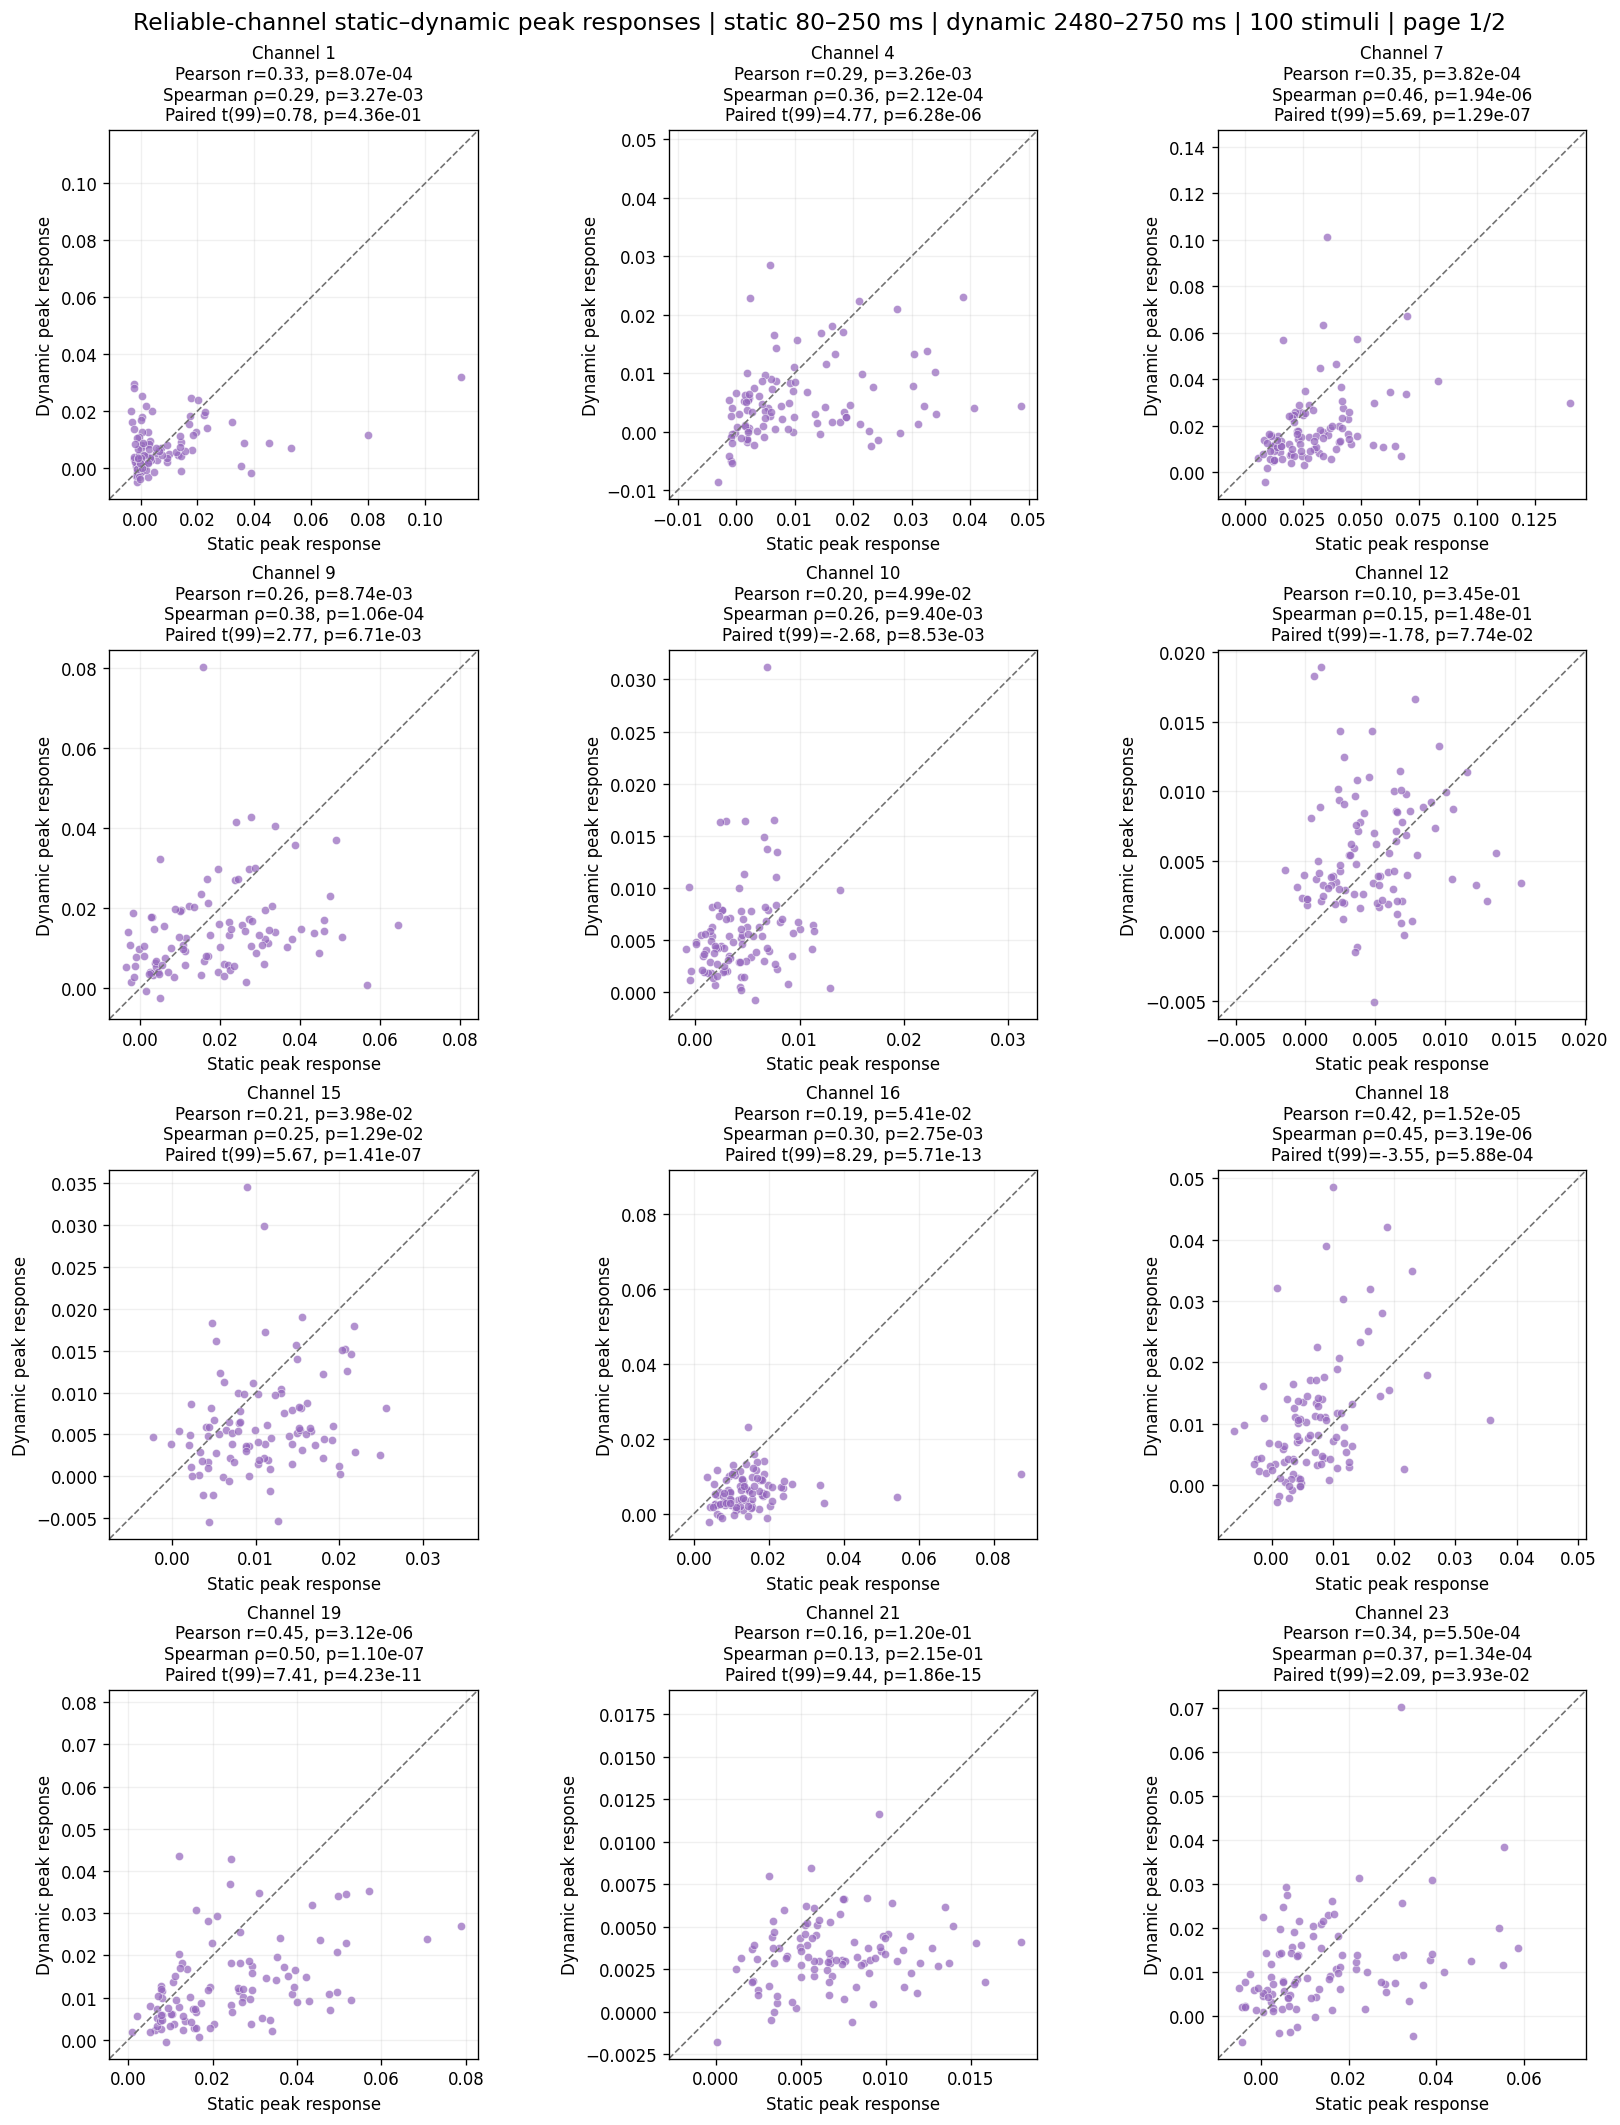

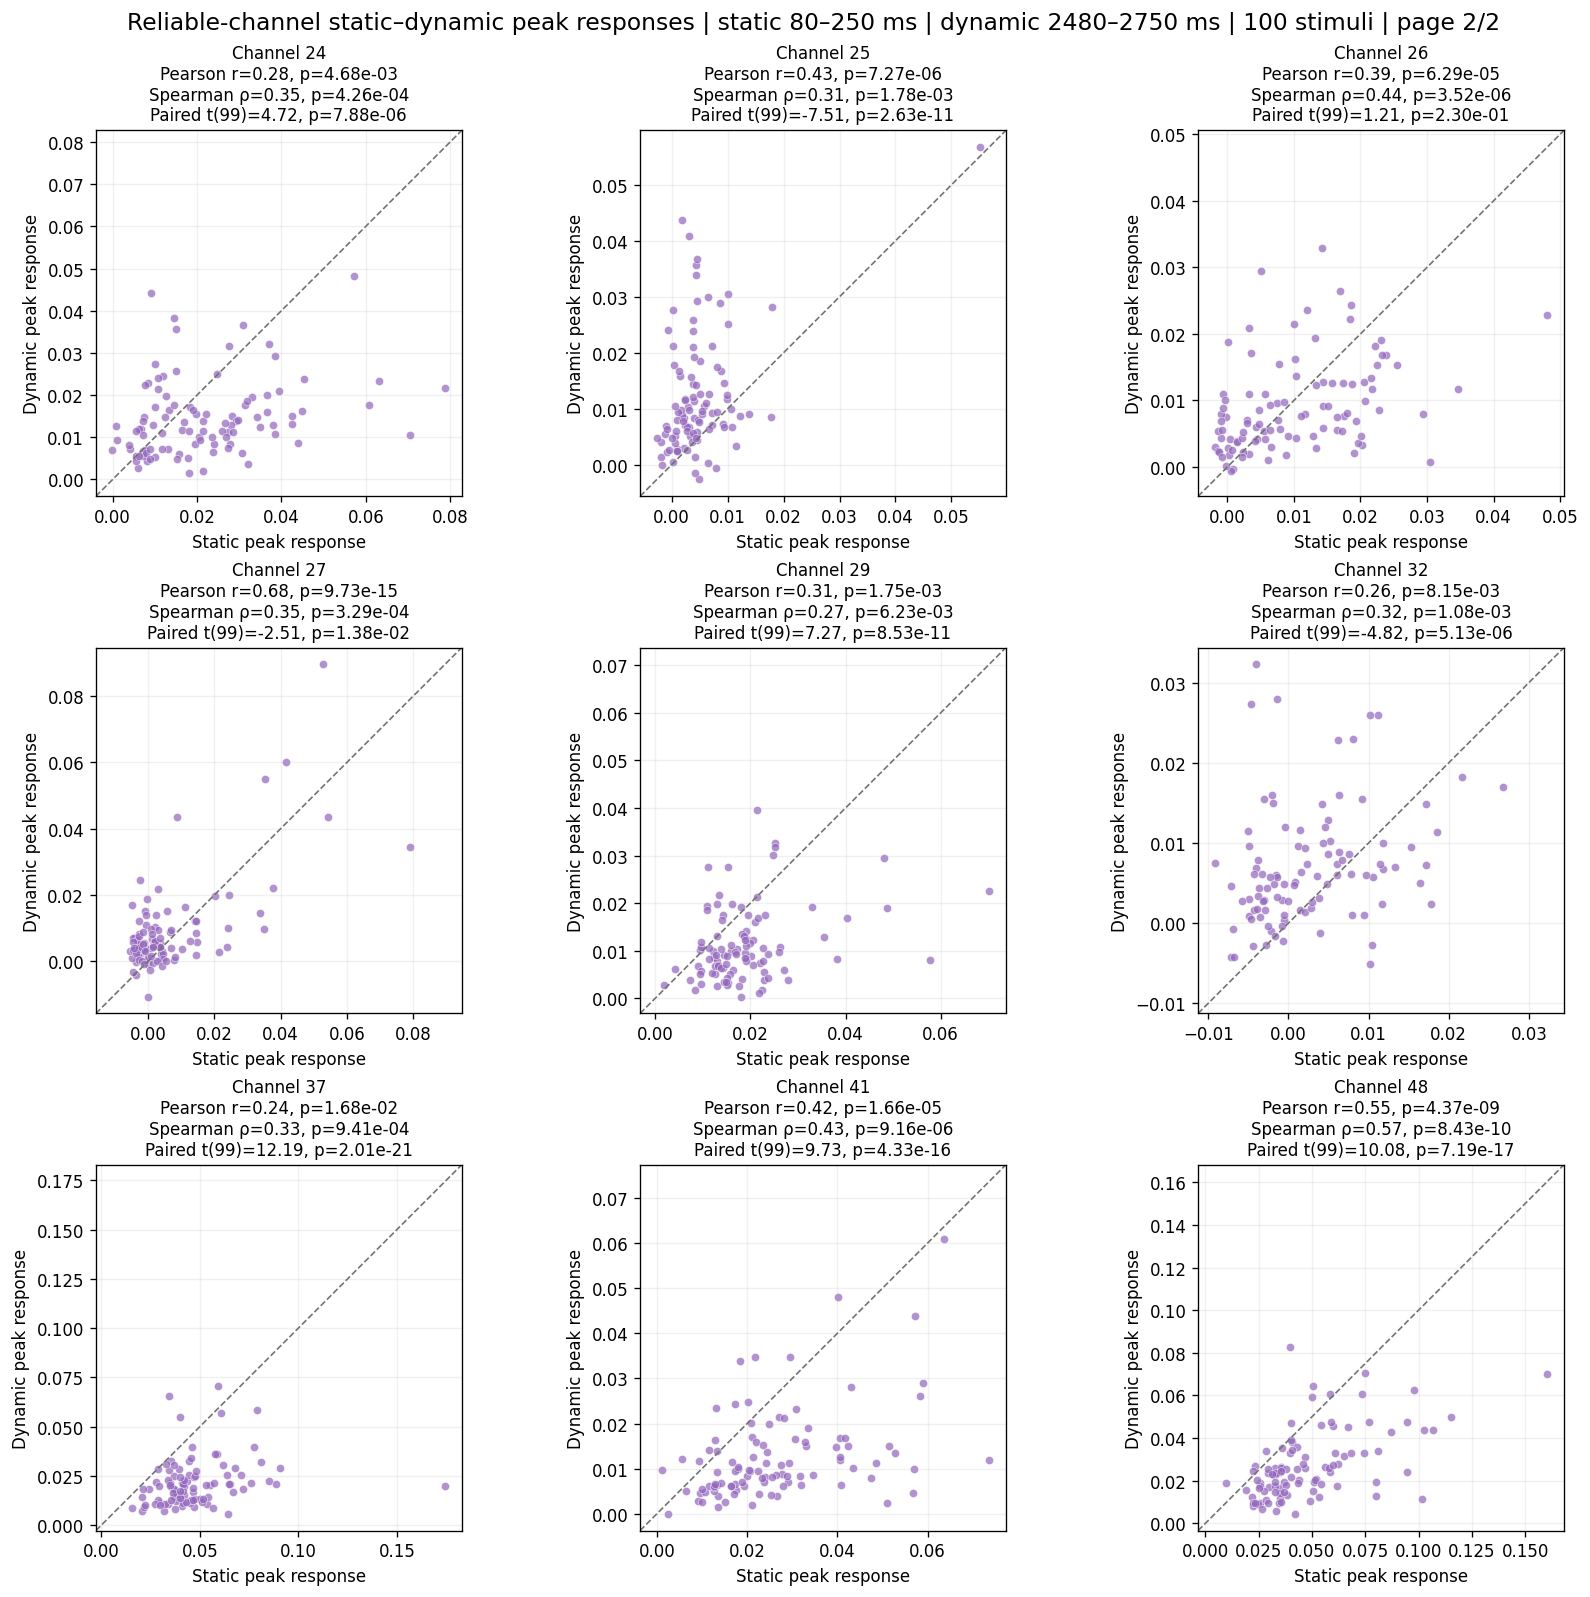

In [15]:
figure_count = int(np.ceil(channel_count / cfg.channels_per_figure))

for figure_index, page_start in enumerate(
        range(0, channel_count, cfg.channels_per_figure), start=1,
        ):
    page_stop = min(page_start + cfg.channels_per_figure, channel_count)
    page_channel_count = page_stop - page_start
    row_count = int(np.ceil(page_channel_count / cfg.subplot_columns))
    figure, axes = plt.subplots(
        row_count, cfg.subplot_columns,
        figsize=(4.6 * cfg.subplot_columns, 4.4 * row_count),
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for panel_index, axis in enumerate(axes):
        channel_index = page_start + panel_index
        if channel_index >= page_stop:
            axis.axis("off")
            continue
        # end if unused panel

        static_responses = static_channel_responses[channel_index]
        dynamic_responses = dynamic_channel_responses[channel_index]
        axis.scatter(
            static_responses, dynamic_responses,
            s=cfg.point_size, alpha=0.72, color="tab:purple",
            edgecolor="white", linewidth=0.35,
        )

        # Use equal limits so position relative to identity is not distorted.
        response_min = min(static_responses.min(), dynamic_responses.min())
        response_max = max(static_responses.max(), dynamic_responses.max())
        response_padding = 0.05 * max(response_max - response_min, 1e-12)
        response_limits = (
            response_min - response_padding,
            response_max + response_padding,
        )
        if cfg.show_identity_line:
            axis.plot(
                response_limits, response_limits, "--",
                color="0.45", linewidth=1, label="Identity",
            )
        # end if cfg.show_identity_line

        pearson_r = channel_pearson_correlations[channel_index]
        pearson_pvalue = channel_pearson_pvalues[channel_index]
        spearman_rho = channel_spearman_correlations[channel_index]
        spearman_pvalue = channel_spearman_pvalues[channel_index]
        paired_t = channel_paired_t_statistics[channel_index]
        paired_ttest_pvalue = channel_paired_ttest_pvalues[channel_index]
        axis.set(
            xlim=response_limits, ylim=response_limits, aspect="equal",
            xlabel=f"Static {cfg.response_summary} response",
            ylabel=f"Dynamic {cfg.response_summary} response",
            title=(
                f"Channel {channel_numbers[channel_index]}"
                f"\nPearson r={pearson_r:.2f}, p={pearson_pvalue:.2e}"
                f"\nSpearman ρ={spearman_rho:.2f}, p={spearman_pvalue:.2e}"
                f"\nPaired t({len(shared_stimuli) - 1})={paired_t:.2f}, "
                f"p={paired_ttest_pvalue:.2e}"
            ),
        )
        axis.title.set_fontsize(10)
        axis.grid(alpha=0.18)
    # end for panel_index, axis

    figure.suptitle(
        f"Reliable-channel static–dynamic {cfg.response_summary} responses | "
        f"static {analysis_static_window_ms[0]:g}–{analysis_static_window_ms[1]:g} ms | "
        f"dynamic {analysis_dynamic_window_ms[0]:g}–"
        f"{analysis_dynamic_window_ms[1]:g} ms | "
        f"{len(shared_stimuli)} stimuli | page {figure_index}/{figure_count}",
        fontsize=14,
    )
    plt.show()
# end for figure_index, page_start

## Channel-wise statistical summaries

The first barplot shows the static–dynamic Spearman correlation for every reliable channel. The second shows the paired t score from `ttest_rel(static, dynamic)`: positive values indicate greater mean static activity, while negative values indicate greater mean dynamic activity.

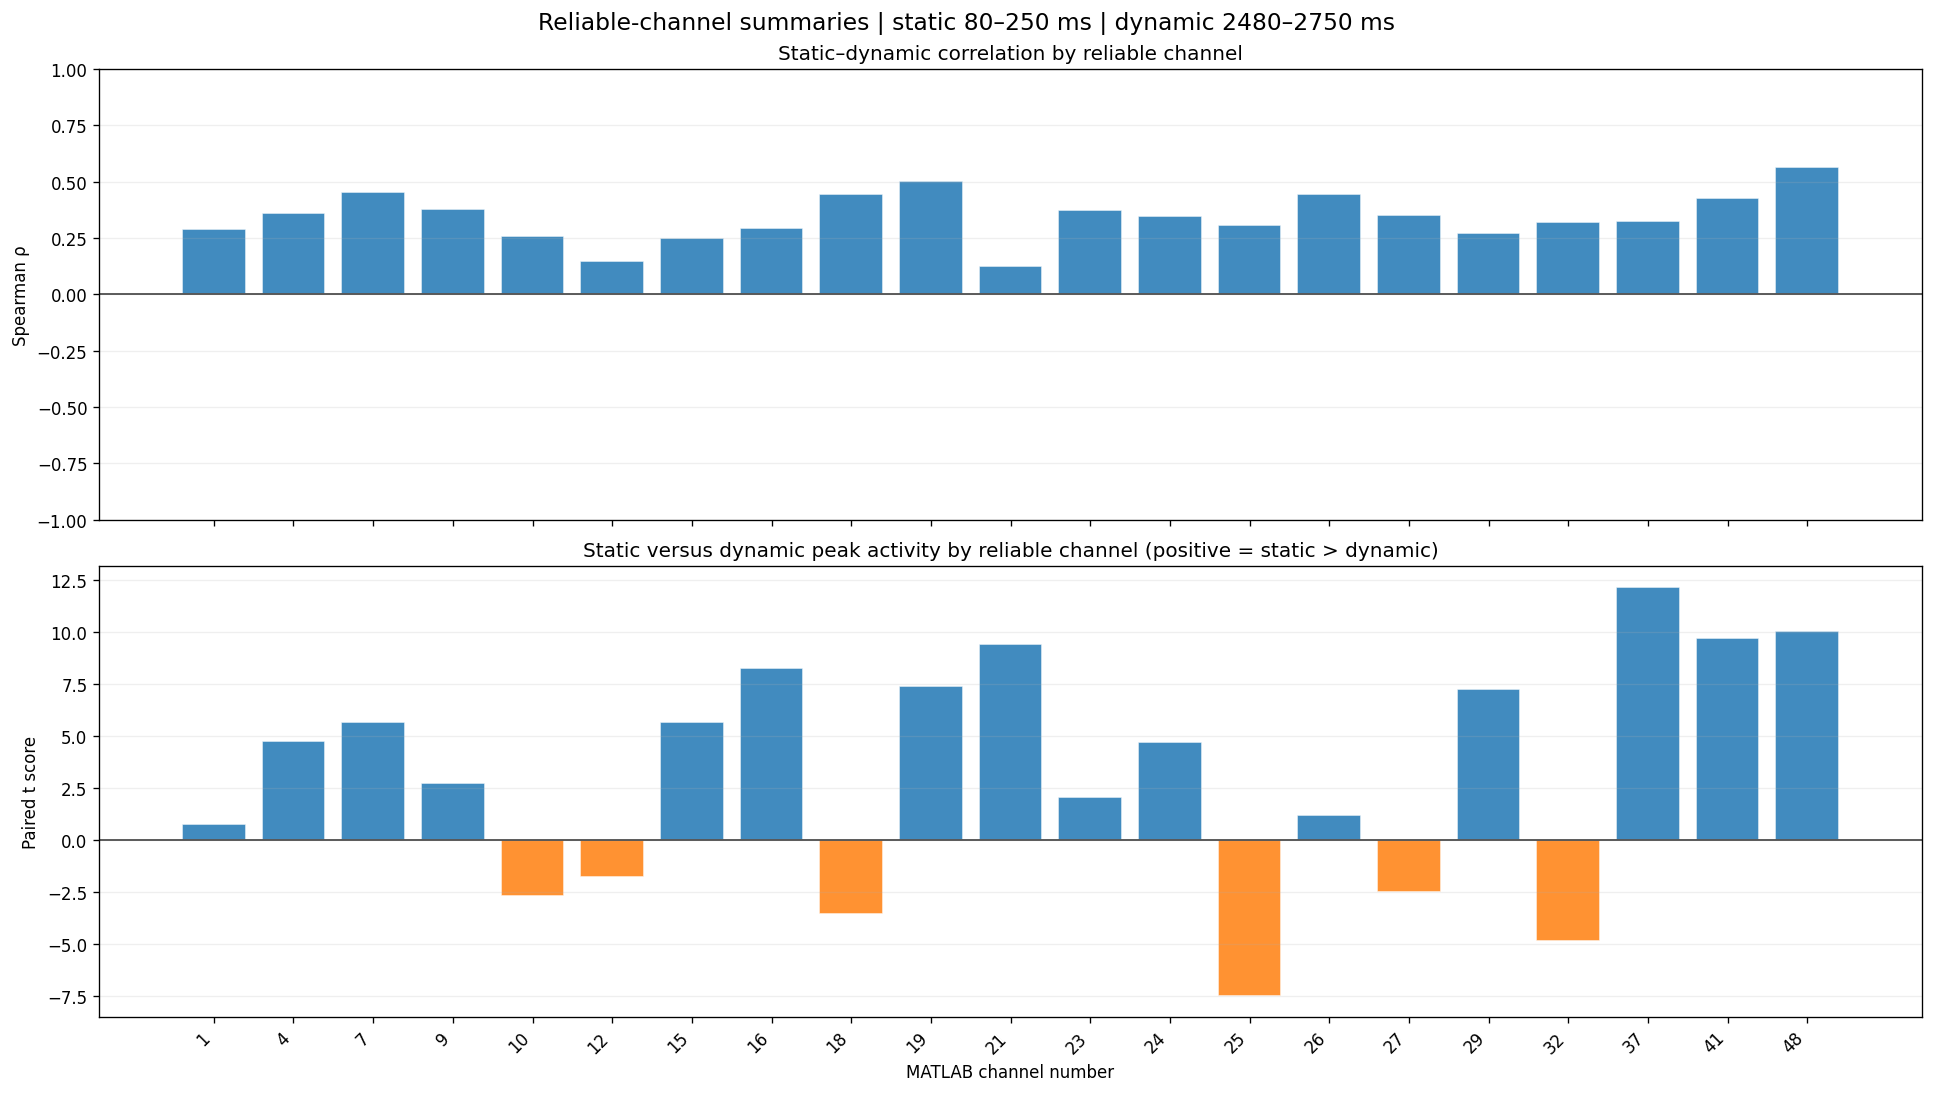

In [16]:
channel_positions = np.arange(channel_count)
correlation_colors = np.where(
    channel_spearman_correlations >= 0, "tab:blue", "tab:red",
)
ttest_colors = np.where(
    channel_paired_t_statistics >= 0, "tab:blue", "tab:orange",
)

figure, axes = plt.subplots(
    2, 1, figsize=(16, 9), sharex=True, constrained_layout=True,
)

# Summarize channel-wise agreement in stimulus preference.
axes[0].bar(
    channel_positions, channel_spearman_correlations,
    color=correlation_colors, alpha=0.85, edgecolor="white",
)
axes[0].axhline(0, color="0.25", linewidth=1)
axes[0].set(
    ylim=(-1, 1),
    ylabel="Spearman ρ",
    title="Static–dynamic correlation by reliable channel",
)
axes[0].grid(axis="y", alpha=0.2)

# Summarize the paired static-minus-dynamic activity difference.
axes[1].bar(
    channel_positions, channel_paired_t_statistics,
    color=ttest_colors, alpha=0.85, edgecolor="white",
)
axes[1].axhline(0, color="0.25", linewidth=1)
axes[1].set(
    ylabel="Paired t score",
    xlabel="MATLAB channel number",
    title=(
        f"Static versus dynamic {cfg.response_summary} activity by reliable channel "
        "(positive = static > dynamic)"
    ),
)
axes[1].set_xticks(channel_positions)
axes[1].set_xticklabels(channel_numbers, rotation=45, ha="right")
axes[1].grid(axis="y", alpha=0.2)

figure.suptitle(
    f"Reliable-channel summaries | "
    f"static {analysis_static_window_ms[0]:g}–{analysis_static_window_ms[1]:g} ms | "
    f"dynamic {analysis_dynamic_window_ms[0]:g}–"
    f"{analysis_dynamic_window_ms[1]:g} ms",
    fontsize=14,
)
plt.show()

## Distributions across reliable channels

These histograms show the distributions of Spearman ρ coefficients and paired t scores across all reliable channels. Change `cfg.histogram_bin_count` to control the number of bins.

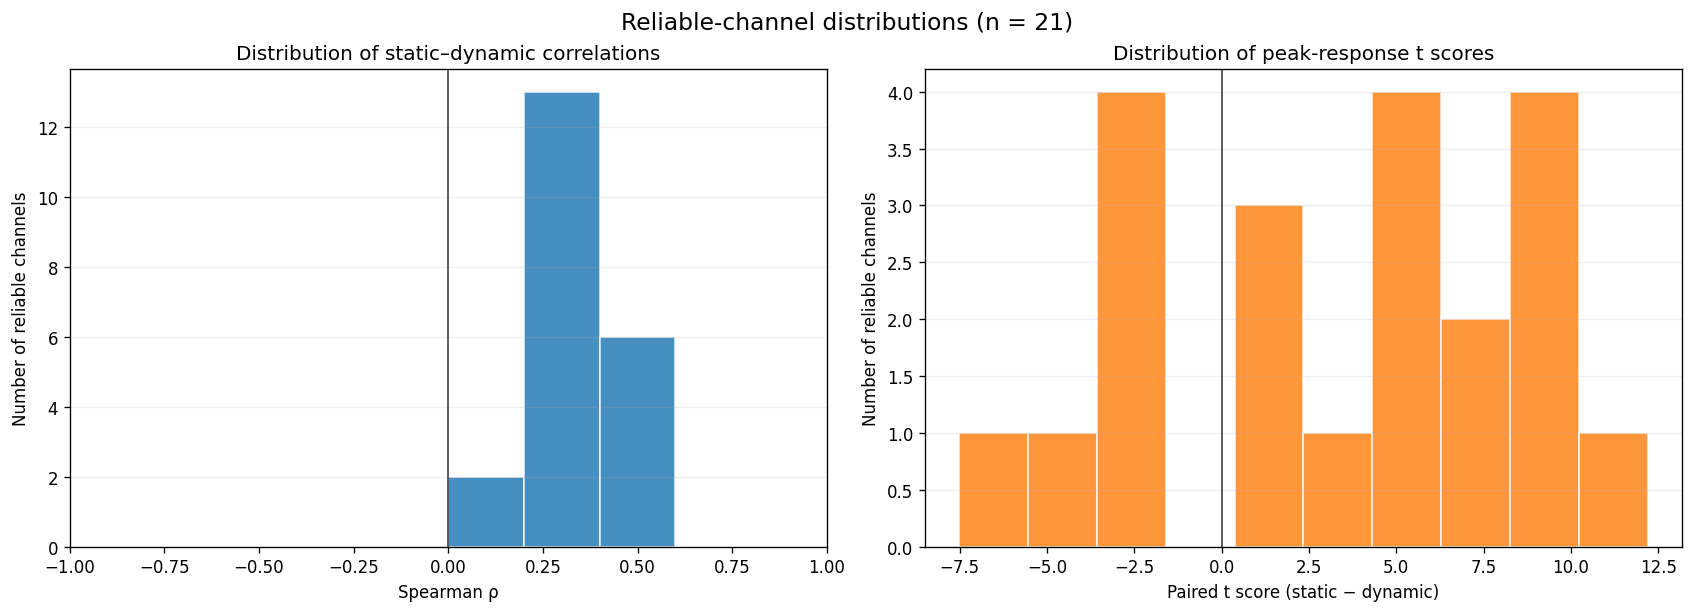

In [17]:
finite_spearman_correlations = channel_spearman_correlations[
    np.isfinite(channel_spearman_correlations)
]
finite_paired_t_statistics = channel_paired_t_statistics[
    np.isfinite(channel_paired_t_statistics)
]

figure, axes = plt.subplots(
    1, 2, figsize=(14, 5), constrained_layout=True,
)

axes[0].hist(
    finite_spearman_correlations,
    bins=np.linspace(-1, 1, cfg.histogram_bin_count + 1),
    color="tab:blue", alpha=0.82, edgecolor="white",
)
axes[0].axvline(0, color="0.25", linewidth=1)
axes[0].set(
    xlim=(-1, 1),
    xlabel="Spearman ρ",
    ylabel="Number of reliable channels",
    title="Distribution of static–dynamic correlations",
)
axes[0].grid(axis="y", alpha=0.2)

axes[1].hist(
    finite_paired_t_statistics, bins=cfg.histogram_bin_count,
    color="tab:orange", alpha=0.82, edgecolor="white",
)
axes[1].axvline(0, color="0.25", linewidth=1)
axes[1].set(
    xlabel="Paired t score (static − dynamic)",
    ylabel="Number of reliable channels",
    title=f"Distribution of {cfg.response_summary}-response t scores",
)
axes[1].grid(axis="y", alpha=0.2)

figure.suptitle(
    f"Reliable-channel distributions (n = {channel_count})",
    fontsize=14,
)
plt.show()

## Peak-latency differences

Static latencies are relative to static-image onset. Movie latencies are relative to the selected frame time (`2500`, `2000`, or `2250` ms, depending on `static_response`). Differences are `static latency − dynamic relative latency`, matching the direction of `ttest_rel(static, dynamic)`: positive values mean the static response peaks later. The barplot shows the mean difference across stimuli for each channel; the histogram shows all channel–stimulus differences.

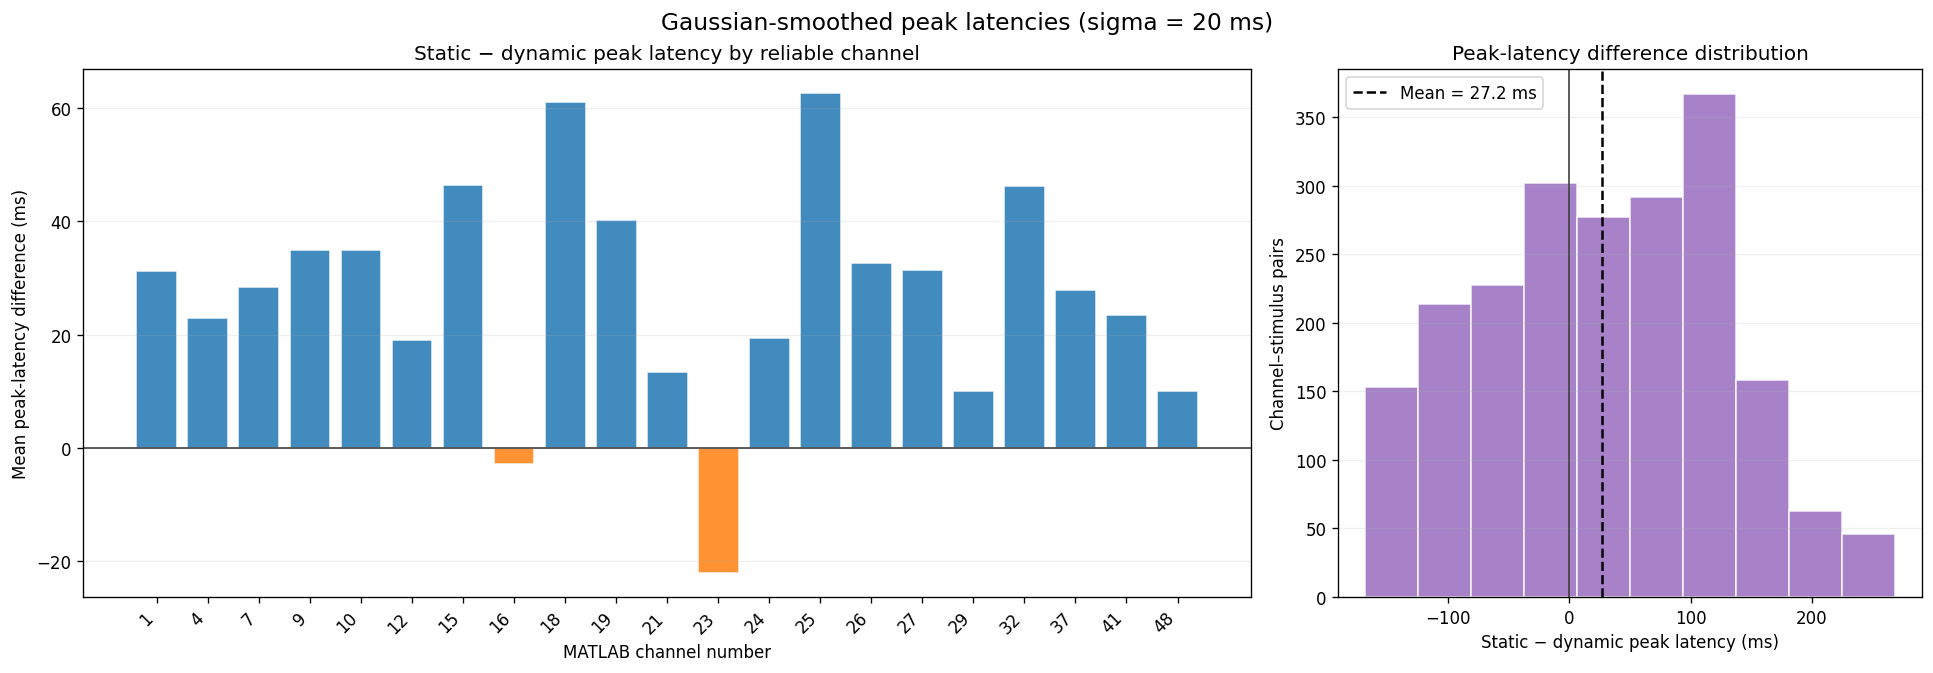

In [18]:
latency_difference_colors = np.where(
    channel_mean_peak_latency_differences_ms >= 0,
    "tab:blue", "tab:orange",
)
figure, axes = plt.subplots(
    1, 2, figsize=(16, 5.5),
    gridspec_kw={"width_ratios": (2, 1)},
    constrained_layout=True,
)

axes[0].bar(
    channel_positions, channel_mean_peak_latency_differences_ms,
    color=latency_difference_colors, alpha=0.85, edgecolor="white",
)
axes[0].axhline(0, color="0.25", linewidth=1)
axes[0].set(
    ylabel="Mean peak-latency difference (ms)",
    xlabel="MATLAB channel number",
    title="Static − dynamic peak latency by reliable channel",
)
axes[0].set_xticks(channel_positions)
axes[0].set_xticklabels(channel_numbers, rotation=45, ha="right")
axes[0].grid(axis="y", alpha=0.2)

finite_peak_latency_differences_ms = peak_latency_differences_ms[
    np.isfinite(peak_latency_differences_ms)
]
axes[1].hist(
    finite_peak_latency_differences_ms, bins=cfg.histogram_bin_count,
    color="tab:purple", alpha=0.82, edgecolor="white",
)
axes[1].axvline(0, color="0.25", linewidth=1)
axes[1].axvline(
    finite_peak_latency_differences_ms.mean(),
    color="black", linestyle="--", linewidth=1.5,
    label=(
        f"Mean = {finite_peak_latency_differences_ms.mean():.1f} ms"
    ),
)
axes[1].set(
    xlabel="Static − dynamic peak latency (ms)",
    ylabel="Channel–stimulus pairs",
    title="Peak-latency difference distribution",
)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.2)

figure.suptitle(
    f"Gaussian-smoothed peak latencies (sigma = "
    f"{cfg.gaussian_smoothing_sigma_ms:g} ms)",
    fontsize=14,
)
plt.show()

## Population latency correlations

For each stimulus, the reliable-channel responses are averaged first to obtain a population timecourse. Each point then compares the latency of that population response between the static image and the matched movie frame. Both measures use Gaussian-smoothed responses; the centroid is the center of positive response mass inside the configured window. Dynamic latencies are expressed relative to the selected frame time.

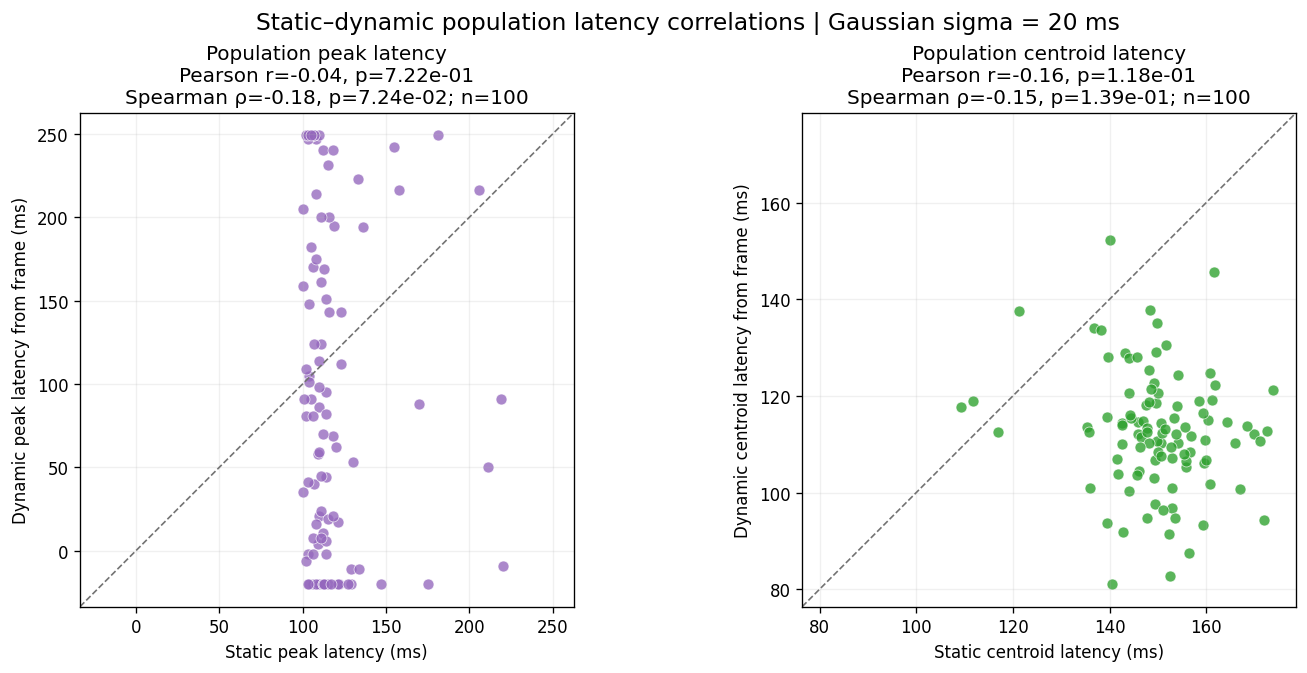

In [19]:
figure, axes = plt.subplots(
    1, 2, figsize=(12, 5.5), constrained_layout=True,
)
latency_colors = {"peak": "tab:purple", "centroid": "tab:green"}

for axis, (latency_name, latency_values) in zip(axes, latency_pairs.items()):
    static_latencies = latency_values[2]
    dynamic_latencies = latency_values[3]
    finite_pairs = (
        np.isfinite(static_latencies) & np.isfinite(dynamic_latencies)
    )
    static_values = static_latencies[finite_pairs]
    dynamic_values = dynamic_latencies[finite_pairs]
    statistics = latency_correlations[latency_name]

    axis.scatter(
        static_values, dynamic_values, s=cfg.point_size * 1.8,
        alpha=0.78, color=latency_colors[latency_name],
        edgecolor="white", linewidth=0.45,
    )
    if len(static_values) > 0:
        latency_min = min(static_values.min(), dynamic_values.min())
        latency_max = max(static_values.max(), dynamic_values.max())
        latency_padding = 0.05 * max(latency_max - latency_min, 1.0)
        latency_limits = (
            latency_min - latency_padding, latency_max + latency_padding,
        )
        if cfg.show_identity_line:
            axis.plot(
                latency_limits, latency_limits, "--",
                color="0.45", linewidth=1,
            )
        # end if cfg.show_identity_line
        axis.set(xlim=latency_limits, ylim=latency_limits, aspect="equal")
    # end if finite population pairs
    axis.set(
        xlabel=f"Static {latency_name} latency (ms)",
        ylabel=f"Dynamic {latency_name} latency from frame (ms)",
        title=(
            f"Population {latency_name} latency"
            f"\nPearson r={statistics['population_pearson_r']:.2f}, "
            f"p={statistics['population_pearson_p']:.2e}"
            f"\nSpearman ρ={statistics['population_spearman_rho']:.2f}, "
            f"p={statistics['population_spearman_p']:.2e}"
            f"; n={statistics['population_valid_count']}"
        ),
    )
    axis.grid(alpha=0.18)
# end for axis, latency_name

figure.suptitle(
    f"Static–dynamic population latency correlations | "
    f"Gaussian sigma = {cfg.gaussian_smoothing_sigma_ms:g} ms",
    fontsize=14,
)
plt.show()

## Single-channel latency correlations

Each panel is one reliable channel and each point is one matched stimulus. Peak and centroid correlations are shown in separate paginated figure sets. Centroids with no positive response mass are omitted pairwise, and each title reports the retained stimulus count.

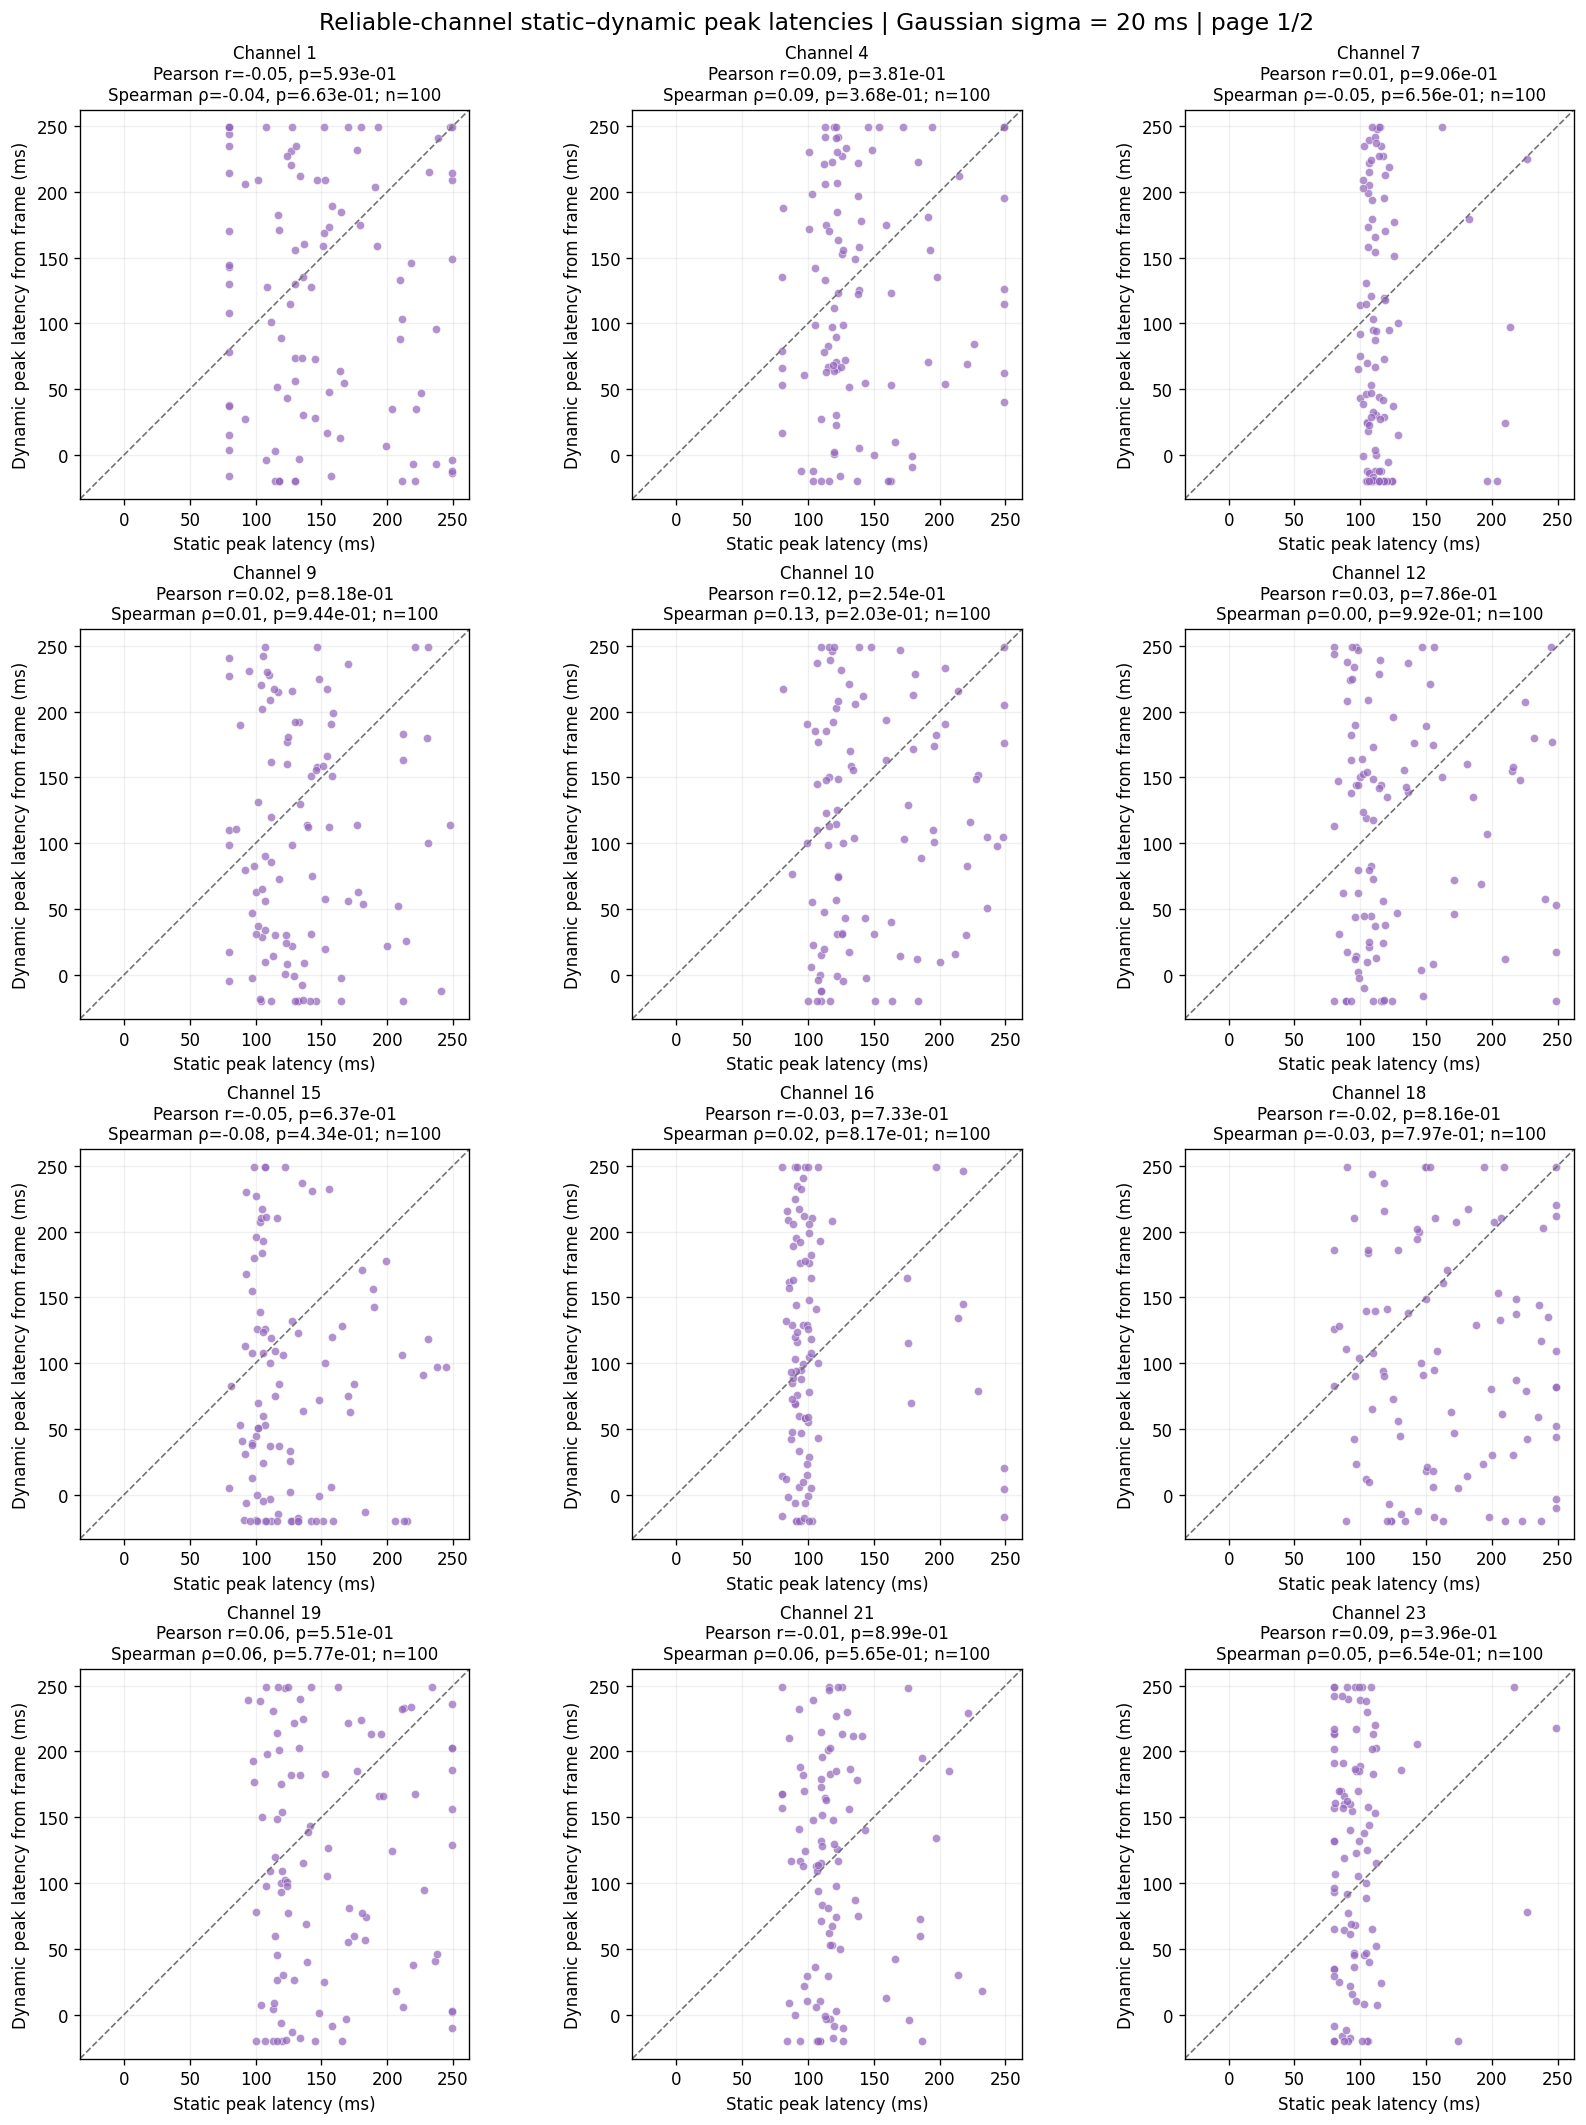

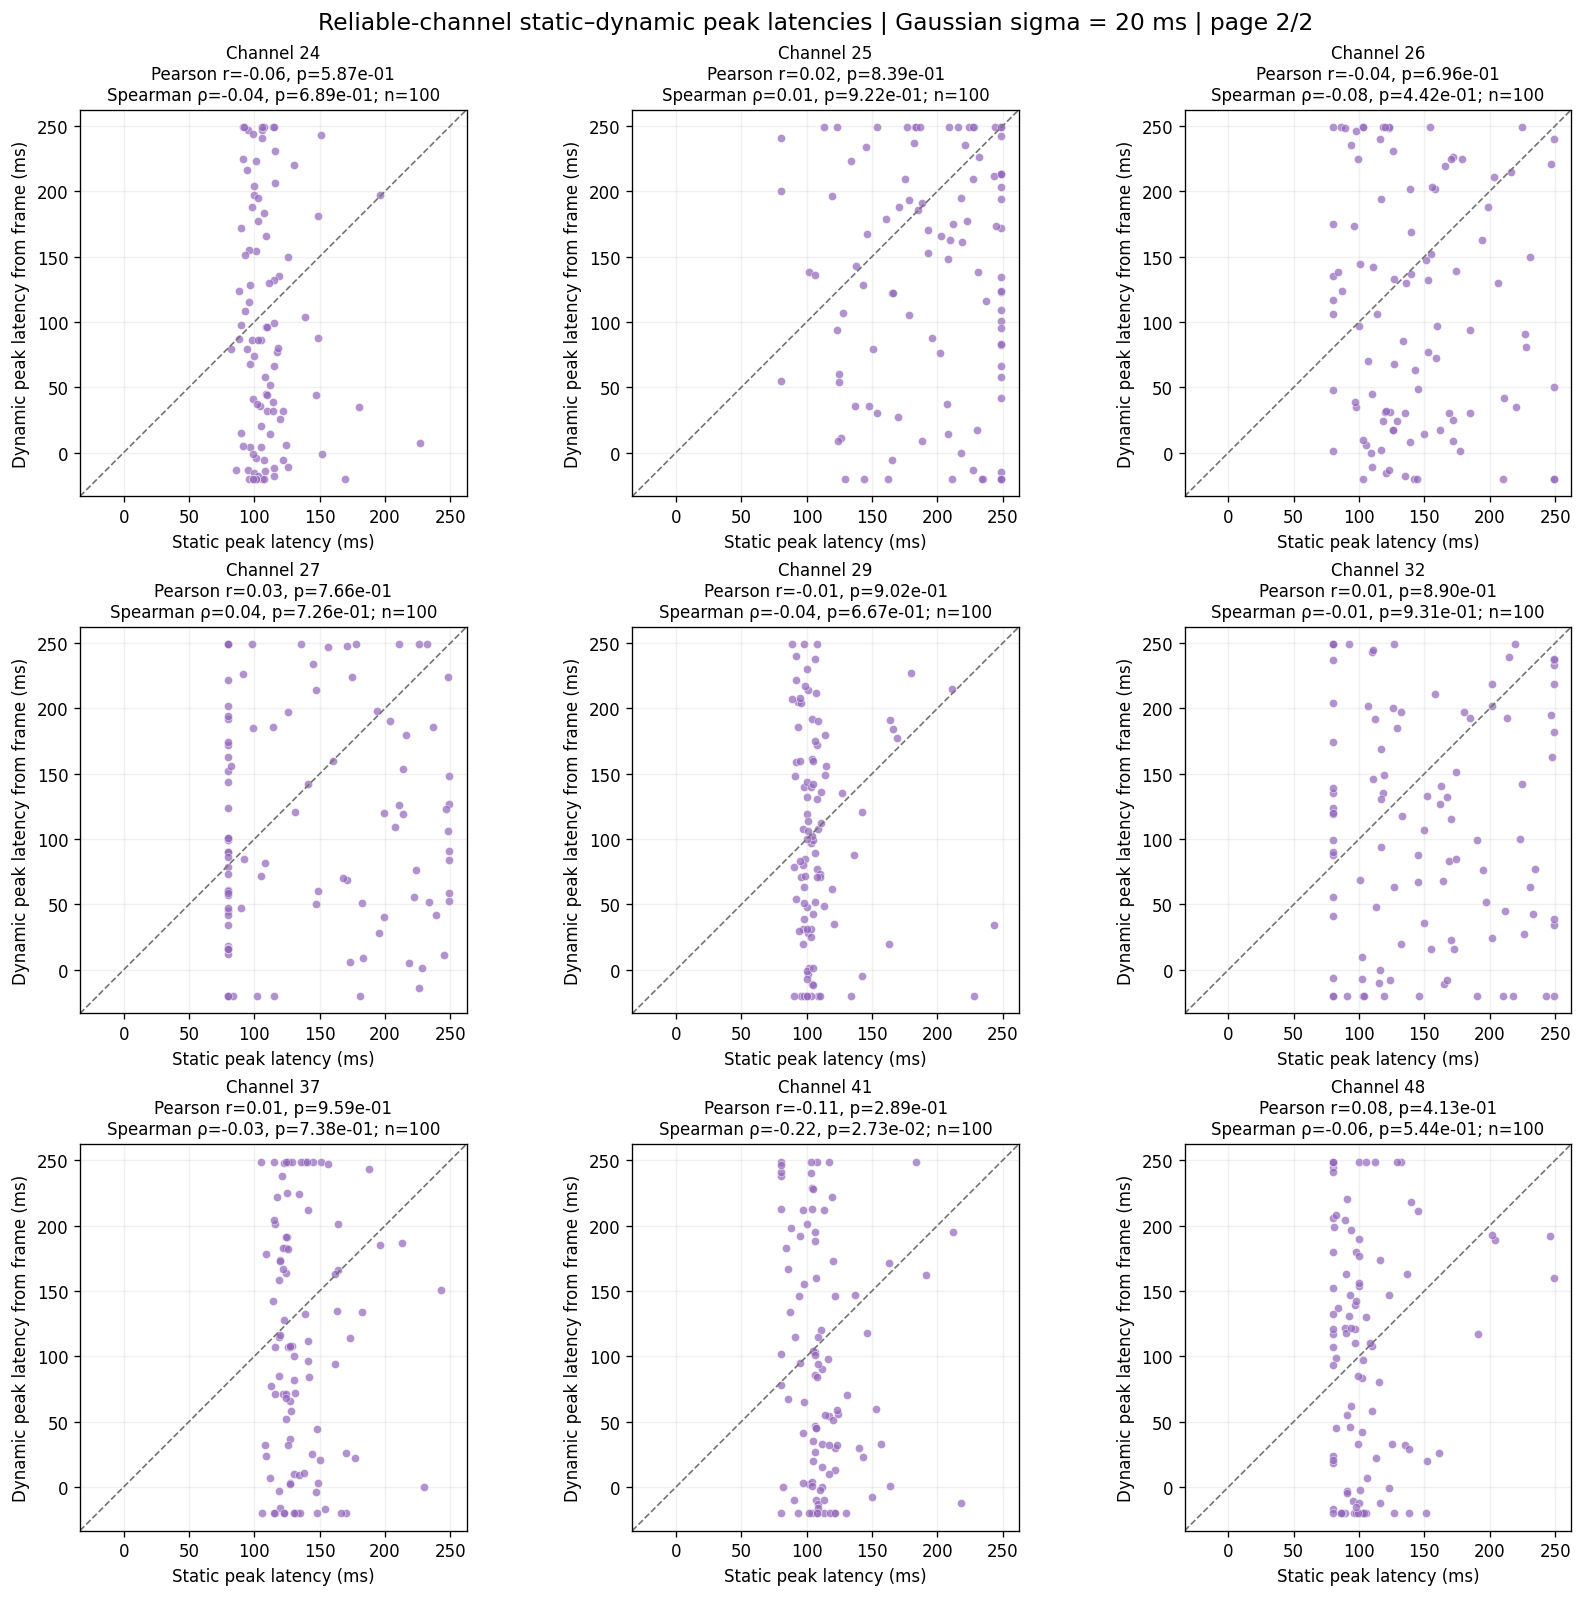

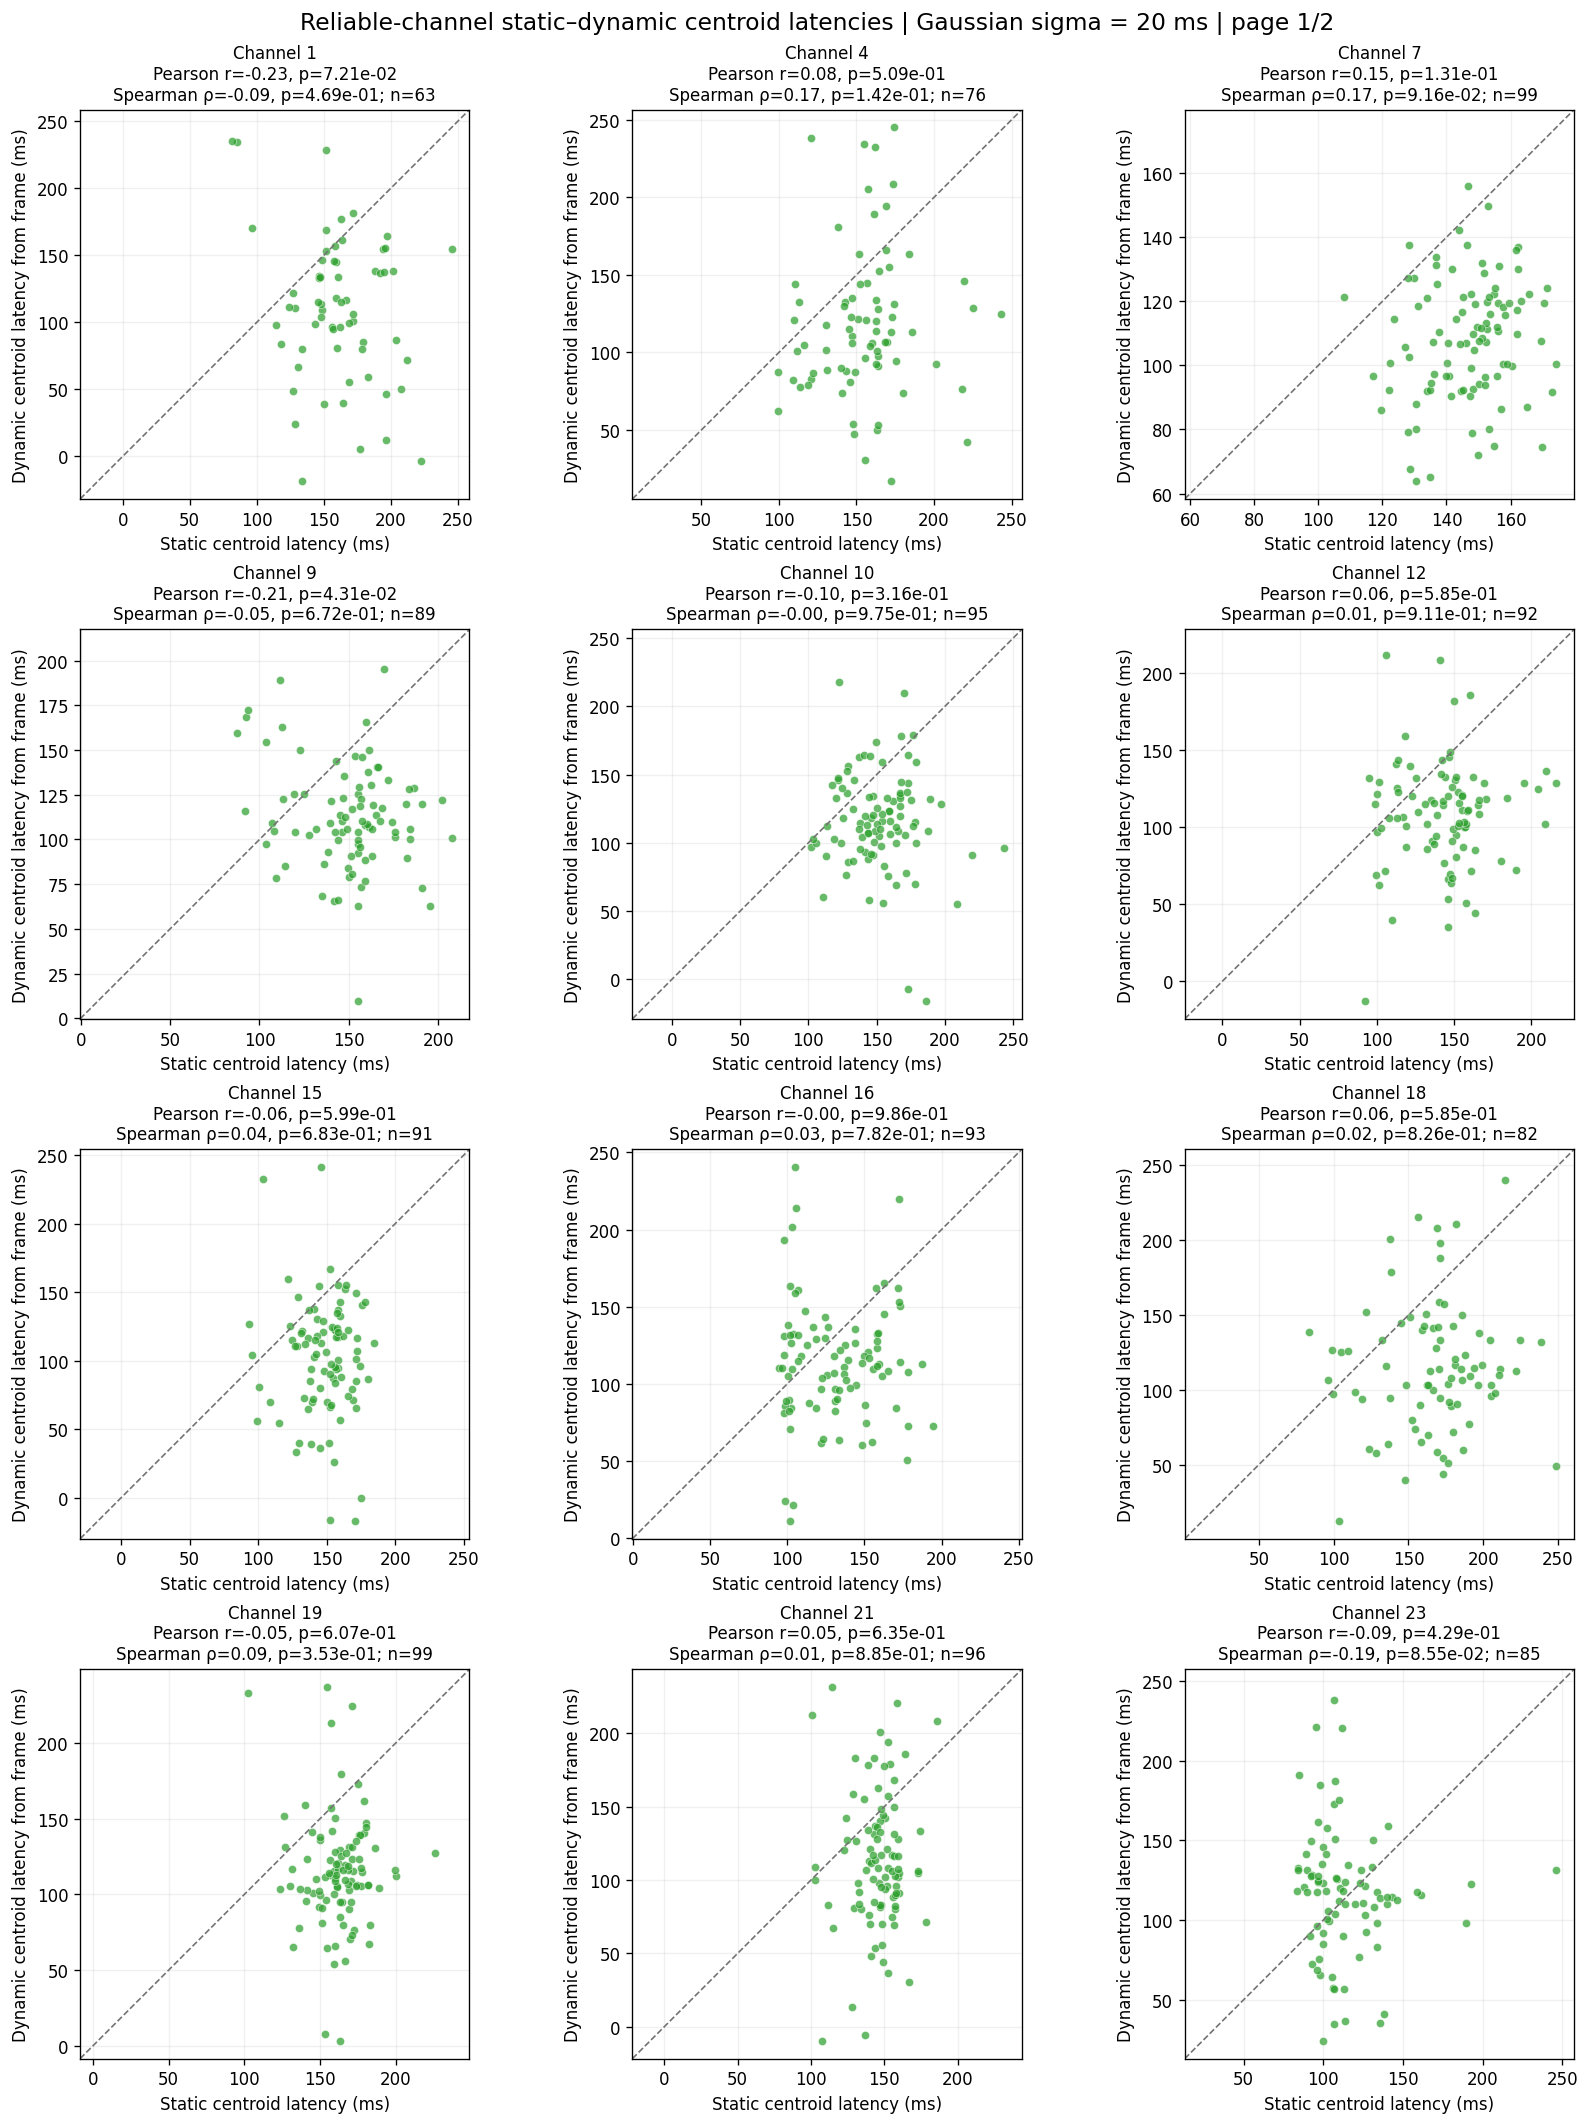

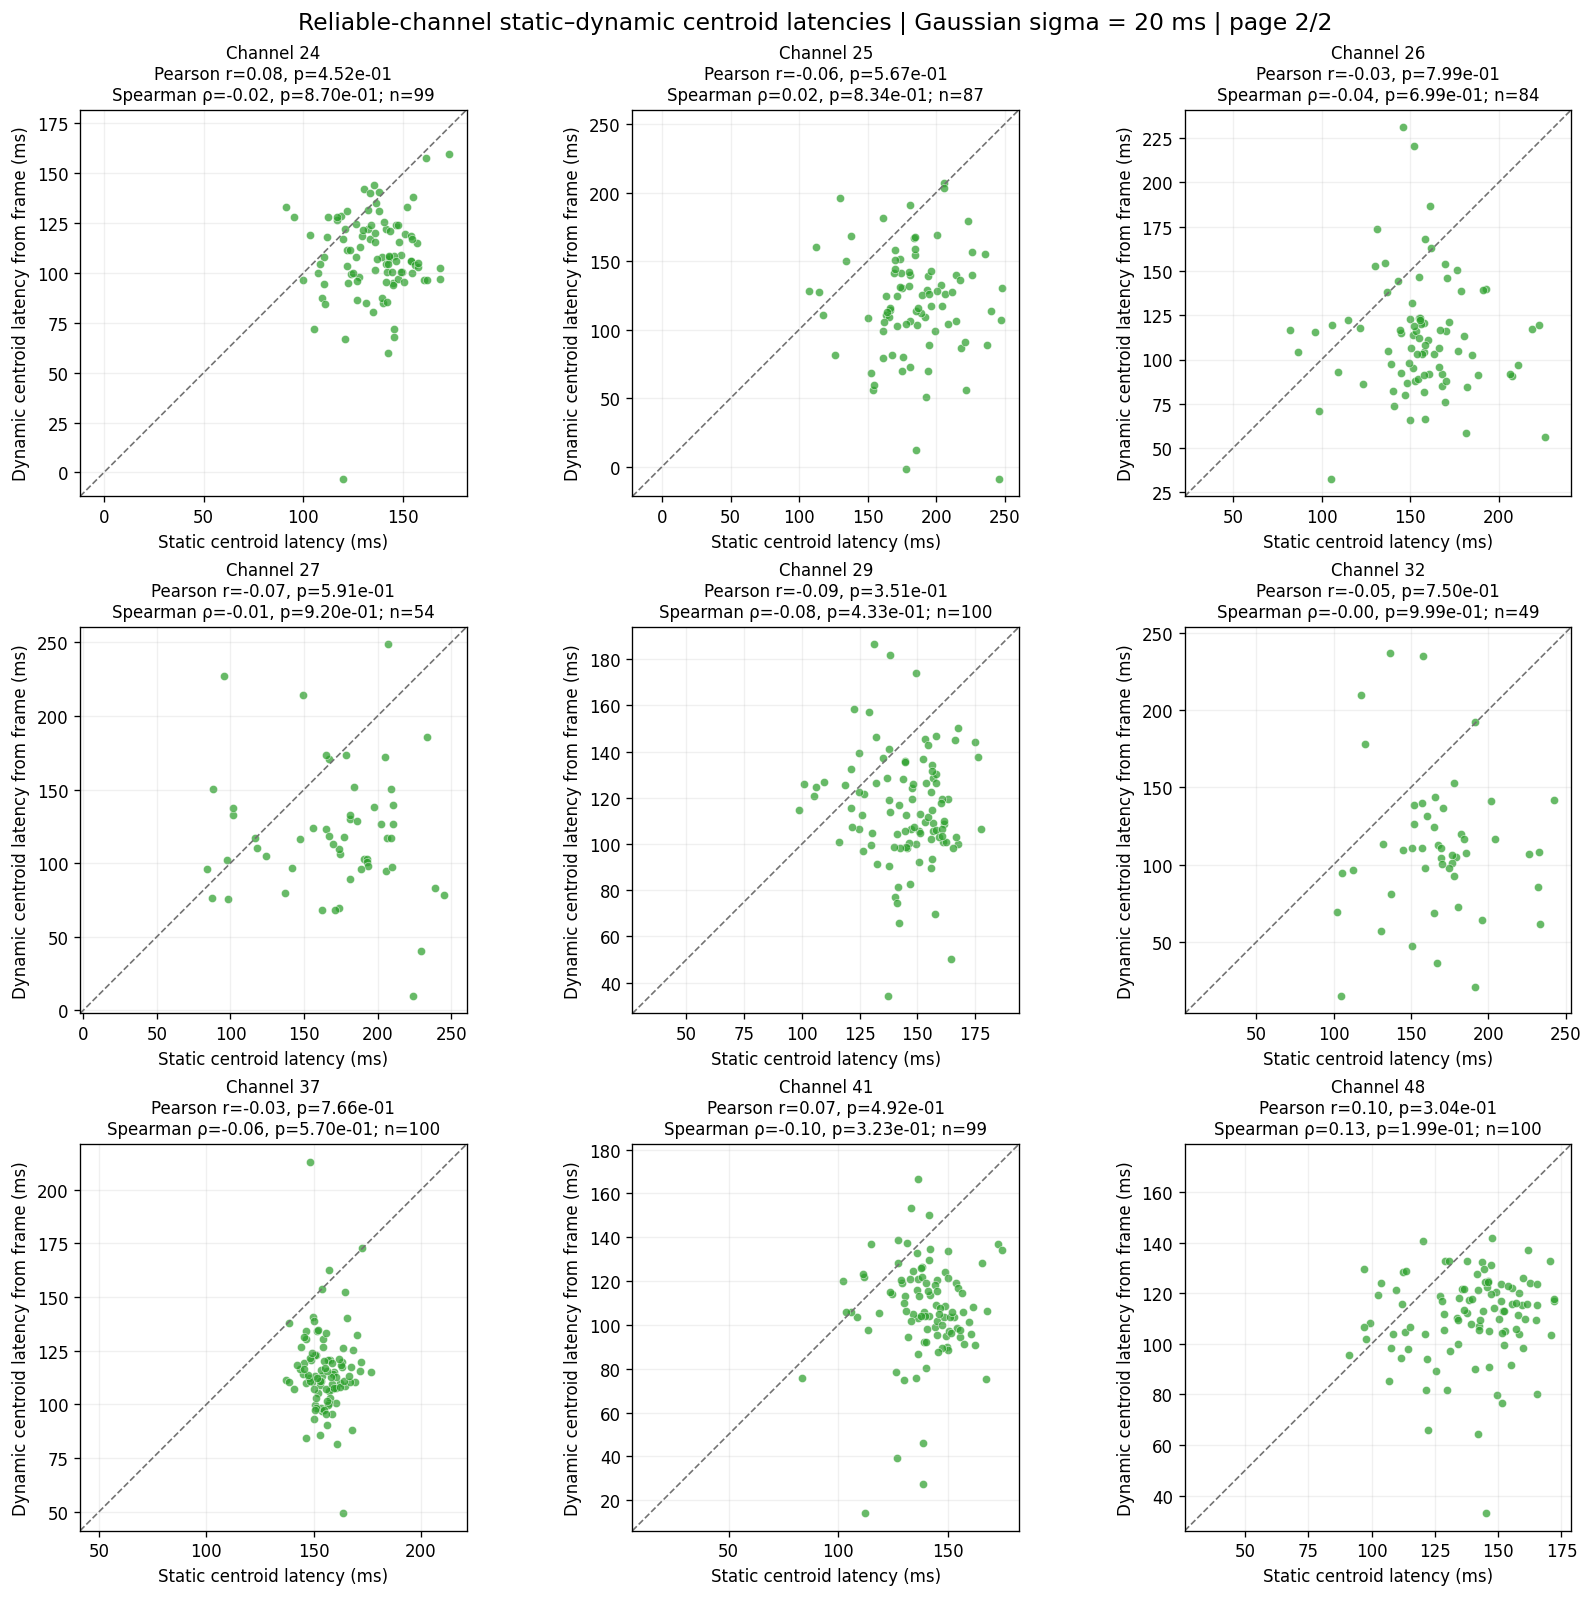

In [20]:
for latency_name, latency_values in latency_pairs.items():
    static_latencies, dynamic_latencies = latency_values[:2]
    statistics = latency_correlations[latency_name]

    for figure_index, page_start in enumerate(
            range(0, channel_count, cfg.channels_per_figure), start=1,
            ):
        page_stop = min(page_start + cfg.channels_per_figure, channel_count)
        page_channel_count = page_stop - page_start
        row_count = int(np.ceil(page_channel_count / cfg.subplot_columns))
        figure, axes = plt.subplots(
            row_count, cfg.subplot_columns,
            figsize=(4.6 * cfg.subplot_columns, 4.4 * row_count),
            constrained_layout=True,
        )
        axes = np.atleast_1d(axes).ravel()

        for panel_index, axis in enumerate(axes):
            channel_index = page_start + panel_index
            if channel_index >= page_stop:
                axis.axis("off")
                continue
            # end if unused panel

            finite_pairs = (
                np.isfinite(static_latencies[channel_index])
                & np.isfinite(dynamic_latencies[channel_index])
            )
            static_values = static_latencies[channel_index, finite_pairs]
            dynamic_values = dynamic_latencies[channel_index, finite_pairs]
            axis.scatter(
                static_values, dynamic_values, s=cfg.point_size,
                alpha=0.72, color=latency_colors[latency_name],
                edgecolor="white", linewidth=0.35,
            )

            if len(static_values) > 0:
                latency_min = min(static_values.min(), dynamic_values.min())
                latency_max = max(static_values.max(), dynamic_values.max())
                latency_padding = 0.05 * max(
                    latency_max - latency_min, 1.0,
                )
                latency_limits = (
                    latency_min - latency_padding,
                    latency_max + latency_padding,
                )
                if cfg.show_identity_line:
                    axis.plot(
                        latency_limits, latency_limits, "--",
                        color="0.45", linewidth=1,
                    )
                # end if cfg.show_identity_line
                axis.set(
                    xlim=latency_limits, ylim=latency_limits, aspect="equal",
                )
            # end if finite channel pairs

            axis.set(
                xlabel=f"Static {latency_name} latency (ms)",
                ylabel=f"Dynamic {latency_name} latency from frame (ms)",
                title=(
                    f"Channel {channel_numbers[channel_index]}"
                    f"\nPearson r="
                    f"{statistics['channel_pearson_r'][channel_index]:.2f}, "
                    f"p={statistics['channel_pearson_p'][channel_index]:.2e}"
                    f"\nSpearman ρ="
                    f"{statistics['channel_spearman_rho'][channel_index]:.2f}, "
                    f"p={statistics['channel_spearman_p'][channel_index]:.2e}"
                    f"; n={statistics['channel_valid_counts'][channel_index]}"
                ),
            )
            axis.title.set_fontsize(10)
            axis.grid(alpha=0.18)
        # end for panel_index, axis

        figure.suptitle(
            f"Reliable-channel static–dynamic {latency_name} latencies | "
            f"Gaussian sigma = {cfg.gaussian_smoothing_sigma_ms:g} ms | "
            f"page {figure_index}/{figure_count}",
            fontsize=14,
        )
        plt.show()
    # end for figure_index, page_start
# end for latency_name, latency_values

## Analysis outputs

The arrays below remain available for follow-up analyses without reloading the rasters. Rows follow `channel_numbers`; columns follow `shared_stimuli`.

In [21]:
scatterplot_results = {
    "static_response": cfg.static_response,
    "response_summary": cfg.response_summary,
    "gaussian_smoothing_sigma_ms": cfg.gaussian_smoothing_sigma_ms,
    "minimum_dynamic_window_start_ms": (
        cfg.minimum_dynamic_window_start_ms
    ),
    "static_window_ms": np.asarray(analysis_static_window_ms),
    "dynamic_window_ms": np.asarray(analysis_dynamic_window_ms),
    "channel_numbers": channel_numbers,
    "shared_stimuli": np.asarray(shared_stimuli),
    "static_mean_responses": static_mean_responses,
    "dynamic_mean_responses": dynamic_mean_responses,
    "static_peak_responses": static_peak_responses,
    "dynamic_peak_responses": dynamic_peak_responses,
    "static_channel_responses": static_channel_responses,
    "dynamic_channel_responses": dynamic_channel_responses,
    "static_peak_latencies_ms": static_peak_latencies_ms,
    "dynamic_peak_latencies_ms": dynamic_peak_latencies_ms,
    "static_peak_latencies_relative_ms": (
        static_peak_latencies_relative_ms
    ),
    "dynamic_peak_latencies_relative_ms": (
        dynamic_peak_latencies_relative_ms
    ),
    "static_centroid_latencies_ms": static_centroid_latencies_ms,
    "dynamic_centroid_latencies_ms": dynamic_centroid_latencies_ms,
    "static_centroid_latencies_relative_ms": (
        static_centroid_latencies_relative_ms
    ),
    "dynamic_centroid_latencies_relative_ms": (
        dynamic_centroid_latencies_relative_ms
    ),
    "population_static_peak_latencies_relative_ms": (
        population_static_peak_latencies_relative_ms
    ),
    "population_dynamic_peak_latencies_relative_ms": (
        population_dynamic_peak_latencies_relative_ms
    ),
    "population_static_centroid_latencies_relative_ms": (
        population_static_centroid_latencies_relative_ms
    ),
    "population_dynamic_centroid_latencies_relative_ms": (
        population_dynamic_centroid_latencies_relative_ms
    ),
    "latency_correlations": latency_correlations,
    "peak_latency_differences_ms": peak_latency_differences_ms,
    "static_minus_dynamic_peak_latency_ms": (
        peak_latency_differences_ms
    ),
    "channel_mean_peak_latency_differences_ms": (
        channel_mean_peak_latency_differences_ms
    ),
    "channel_median_peak_latency_differences_ms": (
        channel_median_peak_latency_differences_ms
    ),
    "static_peak_at_window_edge": static_peak_at_window_edge,
    "dynamic_peak_at_window_edge": dynamic_peak_at_window_edge,
    "channel_pearson_correlations": channel_pearson_correlations,
    "channel_pearson_pvalues": channel_pearson_pvalues,
    "channel_spearman_correlations": channel_spearman_correlations,
    "channel_spearman_pvalues": channel_spearman_pvalues,
    "channel_paired_t_statistics": channel_paired_t_statistics,
    "channel_paired_ttest_pvalues": channel_paired_ttest_pvalues,
}

print("Available scatterplot_results fields:")
print("\n".join(f"- {name}" for name in scatterplot_results))

Available scatterplot_results fields:
- static_response
- response_summary
- gaussian_smoothing_sigma_ms
- minimum_dynamic_window_start_ms
- static_window_ms
- dynamic_window_ms
- channel_numbers
- shared_stimuli
- static_mean_responses
- dynamic_mean_responses
- static_peak_responses
- dynamic_peak_responses
- static_channel_responses
- dynamic_channel_responses
- static_peak_latencies_ms
- dynamic_peak_latencies_ms
- static_peak_latencies_relative_ms
- dynamic_peak_latencies_relative_ms
- static_centroid_latencies_ms
- dynamic_centroid_latencies_ms
- static_centroid_latencies_relative_ms
- dynamic_centroid_latencies_relative_ms
- population_static_peak_latencies_relative_ms
- population_dynamic_peak_latencies_relative_ms
- population_static_centroid_latencies_relative_ms
- population_dynamic_centroid_latencies_relative_ms
- latency_correlations
- peak_latency_differences_ms
- static_minus_dynamic_peak_latency_ms
- channel_mean_peak_latency_differences_ms
- channel_median_peak_latency